# 🧑‍🏫 Aula 7 - Aprendizado Não Supervisionado: Clustering e Detecção de Anomalias em Vibração

---

## 📚 Sumário

1. [Contexto: De Onde Viemos e Para Onde Vamos](#1-contexto-de-onde-viemos-e-para-onde-vamos)
2. [Fundamentos do Aprendizado Não Supervisionado](#2-fundamentos-do-aprendizado-não-supervisionado)
3. [Carregamento e Preparação dos Dados](#3-carregamento-e-preparação-dos-dados)
4. [Parte A — Clustering nos Dados Brutos (ADXL345)](#4-parte-a--clustering-nos-dados-brutos-adxl345)
   - 4.1 Padronização dos Dados
   - 4.2 K-Means: O Algoritmo Mais Popular
   - 4.3 Método do Cotovelo (Elbow Method)
   - 4.4 Análise de Silhueta
   - 4.5 Interpretação dos Clusters vs. Rótulos Reais
5. [Parte B — DBSCAN: Clustering Baseado em Densidade](#5-parte-b--dbscan-clustering-baseado-em-densidade)
   - 5.1 Como o DBSCAN Funciona
   - 5.2 Aplicação e Detecção de Anomalias
6. [Parte C — Clustering Hierárquico (Dendrograma)](#6-parte-c--clustering-hierárquico-dendrograma)
7. [Parte D — Clustering nas Features Engenheiradas](#7-parte-d--clustering-nas-features-engenheiradas)
   - 7.1 Por que Usar Features Engenheiradas?
   - 7.2 K-Means nas 27 Features
   - 7.3 Visualização com PCA (Prévia da Aula 8)
8. [Comparação: Supervisionado vs. Não Supervisionado](#8-comparação-supervisionado-vs-não-supervisionado)
9. [Simulação de Alerta em Tempo Real](#9-simulação-de-alerta-em-tempo-real)
10. [Exportação dos Modelos (.joblib)](#10-exportação-dos-modelos-joblib)
11. [Importação e Predição em "Novo Sistema"](#11-importação-e-predição-em-novo-sistema)
12. [Resumo e Conclusões](#12-resumo-e-conclusões)

---

## 🎯 Capacidades Técnicas Trabalhadas

- **Implantar classificação não supervisionada** para agrupamento de elementos similares.
- **Selecionar o método mais adequado** para o reconhecimento de padrões.
- **Comparar abordagens supervisionadas e não supervisionadas** no mesmo domínio de aplicação.
- **Detectar anomalias** usando técnicas baseadas em distância e densidade.

## 🤝 Capacidades Socioemocionais Trabalhadas

- **Aprendizagem ativa** — Questionar "por que este cluster se formou assim?".
- **Pensamento crítico** — Avaliar quando usar supervisionado vs. não supervisionado.
- **Resolução de problemas complexos** — Lidar com dados sem rótulos.

---

## 1. Contexto: De Onde Viemos e Para Onde Vamos

### 📖 Recapitulação do Nosso Pipeline

| Aula | O que fizemos | Resultado |
|------|--------------|-----------|
| **Aula 5** | Feature Engineering — transformamos 1082 leituras brutas em 32 janelas × 27 features | `vibration_features.csv` |
| **Aula 6** | Classificação Supervisionada — treinamos SVM, Random Forest e Logistic Regression | 3 modelos `.joblib` exportados |
| **Aula 7 (HOJE)** | Aprendizado Não Supervisionado — descobrir padrões SEM usar rótulos | Clusters, anomalias, alertas |
| **Aula 8** | Redução de Dimensionalidade — PCA e UMAP para visualizar dados complexos | Preparação para produção |

### 🤔 O Problema: E Se Não Tivermos Rótulos?

Na Aula 6, tínhamos uma coluna `label` dizendo `yes` (erro) ou `no` (sem erro). Mas no mundo real:

- **Rotular dados é caro e demorado** — alguém precisa parar a produção e inspecionar cada peça
- **Erros novos podem surgir** — um tipo de defeito que nunca foi catalogado
- **O cenário muda** — a máquina desgasta, filamento novo, temperatura diferente
- **Muitas empresas simplesmente não têm rótulos** — só têm os dados dos sensores, sem anotação

> **💡 Analogia:** Na Aula 6, fizemos como um professor que corrige provas com gabarito (supervisionado). Hoje, vamos dar as provas a um aluno que **nunca viu o gabarito** e pedir que ele agrupe as respostas por similaridade (não supervisionado). O surpreendente é que ele muitas vezes consegue!

### 🎯 Por Que Isso Importa na Indústria?

1. **Detecção de defeitos desconhecidos:** Um cluster novo aparecendo pode significar um tipo de falha que os engenheiros ainda não catalogaram
2. **Manutenção preditiva:** Monitorar se os dados "migram" de um cluster para outro pode indicar desgaste
3. **Redução de custos:** Não precisar de um especialista rotulando cada peça

### 📊 Quais Dados Usaremos?

Nesta aula, trabalharemos com **dois datasets** e explicaremos por que cada um é relevante:

| Dataset | Descrição | Uso na Aula |
|---------|-----------|-------------|
| `ADXL345_SensorData.csv` | 1082 leituras brutas (X, Y, Z) | **Parte A/B/C** — Ideal para demonstrar clustering (muitos pontos, 3D fácil de visualizar) |
| `vibration_features.csv` | 32 janelas × 27 features engenheiradas | **Parte D** — Mostra o poder das features; prepara terreno para Aula 8 (redução de dimensionalidade) |

> **⚠️ Por que usar ambos?** Os dados brutos (1082 pontos) são melhores para **visualizar e entender** os algoritmos. As features engenheiradas (27 dimensões) são melhores para **resultados práticos**, mas precisam de redução de dimensionalidade para visualizar — assunto da **Aula 8**!

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais (consistentes com aulas anteriores)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [14, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Paleta de cores consistente
COLORS = {'no': '#2ecc71', 'yes': '#e74c3c'}

print("✅ Bibliotecas carregadas com sucesso!")
print("📦 Sklearn, Scipy, Joblib — prontos para clustering!")

✅ Bibliotecas carregadas com sucesso!
📦 Sklearn, Scipy, Joblib — prontos para clustering!


---

## 2. Fundamentos do Aprendizado Não Supervisionado

### 🧠 O Que É Aprendizado Não Supervisionado?

No **aprendizado supervisionado** (Aula 6), tínhamos:
- **Entrada (X):** Features de vibração
- **Saída (y):** Rótulo dizendo "erro" ou "sem erro"
- O modelo **aprende a mapear X → y** usando exemplos rotulados

No **aprendizado não supervisionado**, temos:
- **Apenas a entrada (X):** Features de vibração
- **Nenhum rótulo (y):** Não sabemos o que é "erro" ou "sem erro"
- O modelo **descobre estrutura nos dados por conta própria**

### 📋 Tipos Principais de Aprendizado Não Supervisionado

| Tipo | Objetivo | Algoritmos | Quando Usar |
|------|----------|------------|-------------|
| **Clustering** | Agrupar dados similares | K-Means, DBSCAN, Hierárquico | Descobrir tipos/padrões nos dados |
| **Detecção de Anomalias** | Encontrar pontos "estranhos" | DBSCAN, Isolation Forest, LOF | Qualidade, segurança, fraude |
| **Redução de Dimensionalidade** | Comprimir muitas features | PCA, UMAP, t-SNE | Visualização, pré-processamento (Aula 8) |
| **Aprendizado de Representação** | Criar features melhores | Autoencoders, Word2Vec | Deep learning, NLP |

### 🏭 No Contexto da Nossa Impressora 3D

Imagine que você tem o sensor ADXL345 rodando 24/7 na fábrica:
- Os dados chegam em streaming (X, Y, Z a cada fração de segundo)
- **Ninguém fica olhando** cada leitura — é impossível rotular manualmente
- Mas você quer ser **alertado** quando algo estranho acontece

O aprendizado não supervisionado permite:
1. **K-Means:** "Existem 2 padrões distintos nos dados — será que um deles é defeito?"
2. **DBSCAN:** "99% dos dados formam um grupo denso, mas estes 15 pontos estão isolados — ALERTA!"
3. **Hierárquico:** "Existe uma hierarquia de subgrupos — diferentes tipos de operação normal?"

In [46]:
# ============================================================
# 3. Carregamento e Preparação dos Dados
# ============================================================

# --- 3.1 Dados Brutos (Raw) ---
raw_path = Path("Dataset/ADXL345_SensorData.csv")
df_raw = pd.read_csv(raw_path)

print("=" * 60)
print("📊 DATASET BRUTO (ADXL345_SensorData.csv)")
print("=" * 60)
print(f"   Dimensões: {df_raw.shape[0]} leituras × {df_raw.shape[1]} colunas")
print(f"   Colunas:   {df_raw.columns.tolist()}")
print(f"\n   Distribuição das classes (Error_found):")
print(f"   {df_raw['Error_found'].value_counts().to_string()}")
print(f"\n   Primeiras 5 linhas:")
display(df_raw.head())

# --- 3.2 Features Engenheiradas (da Aula 5) ---
feat_path = Path("processed_data/vibration_features.csv")
df_feat = pd.read_csv(feat_path)

print("\n" + "=" * 60)
print("📊 DATASET DE FEATURES (vibration_features.csv)")
print("=" * 60)
print(f"   Dimensões: {df_feat.shape[0]} janelas × {df_feat.shape[1]} colunas")
print(f"   Features:  {df_feat.shape[1] - 1} numéricas + 1 label")
print(f"\n   Distribuição das classes (label):")
print(f"   {df_feat['label'].value_counts().to_string()}")
print(f"\n   Primeiras 5 linhas:")
display(df_feat.head())

📊 DATASET BRUTO (ADXL345_SensorData.csv)
   Dimensões: 1082 leituras × 4 colunas
   Colunas:   ['X-direction', 'Y-direction', 'Z-direction', 'Error_found']

   Distribuição das classes (Error_found):
   Error_found
yes    833
no     249

   Primeiras 5 linhas:


,X-direction,Y-direction,Z-direction,Error_found
0,0.31,1.02,-9.18,no
1,-0.78,0.98,-9.10,no
2,0.04,0.67,-8.28,no
3,-0.04,0.90,-8.16,no
4,0.00,1.26,-7.77,no



📊 DATASET DE FEATURES (vibration_features.csv)
   Dimensões: 32 janelas × 28 colunas
   Features:  27 numéricas + 1 label

   Distribuição das classes (label):
   label
yes    25
no      7

   Primeiras 5 linhas:


,X_rms,X_mean,X_std,X_max,X_min,X_kurt,X_skew,Y_rms,Y_mean,Y_std,...,Z_min,Z_kurt,Z_skew,X_fft_mean,X_fft_max,Y_fft_mean,Y_fft_max,Z_fft_mean,Z_fft_max,label
0,0.257221,-0.086875,0.242106,0.35,-0.78,0.944960,-0.951318,0.906592,0.870938,0.251748,...,-10.36,0.279552,0.197463,1.839632,5.56,3.531030,55.74,22.438767,514.130000,no
1,0.235965,-0.079219,0.222270,0.39,-0.67,0.186188,-0.443129,0.925059,0.890000,0.252259,...,-10.40,0.384361,0.104410,1.645735,5.07,3.537728,56.96,21.871856,510.170000,no
2,0.216643,-0.098125,0.193147,0.39,-0.63,0.767153,-0.271542,1.025103,1.006094,0.196498,...,-10.40,-1.971454,0.114611,1.524749,6.28,3.356793,64.39,39.778074,396.299036,no
3,0.204496,-0.124062,0.162565,0.16,-0.86,5.599927,-1.786193,1.082573,1.074219,0.134232,...,-8.47,26.987440,-5.379846,1.442084,7.94,3.105686,68.75,46.435509,699.240000,no
4,0.304102,-0.130000,0.274915,0.16,-1.84,21.489010,-4.074285,1.087833,1.076563,0.156187,...,11.18,1.099122,-0.056630,2.250572,8.32,3.241425,68.90,24.096462,739.790000,no


---

## 4. Parte A — Clustering nos Dados Brutos (ADXL345)

### 🔍 Por que começar pelos dados brutos?

Começamos com os **dados brutos (3 features: X, Y, Z)** por razões pedagógicas:
1. **Fácil de visualizar** — 3D é o máximo que conseguimos plotar diretamente
2. **Muitas amostras** — 1082 pontos formam clusters mais visíveis que 32
3. **Intuição geométrica** — ver os clusters se formando ajuda a entender os algoritmos
4. **Depois** (Parte D), faremos o mesmo com as 27 features engenheiradas

### 4.1 Padronização dos Dados

Antes de qualquer clustering, precisamos **padronizar** (normalizar) os dados. Isto é **crítico** porque:

- **K-Means usa distância Euclidiana**: Se o eixo Z varia de -10 a +11 e o eixo X varia de -1 a +1, o Z domina completamente o cálculo de distância
- **O algoritmo "pensaria" que todos os pontos são parecidos em X** (porque a variação é pequena) e só olharia para Z
- **Padronizar (média=0, desvio=1)** coloca todas as features na mesma escala, dando importância igual a cada eixo

> **💡 Analogia:** É como comparar peso (em kg) com altura (em cm). Sem padronizar, um algoritmo baseado em distância diria que duas pessoas com 170cm e 180cm são "mais diferentes" que pessoas com 60kg e 120kg — porque a diferença em centímetros é maior em magnitude! Padronizar resolve isso.

In [47]:
# --- 4.1 Separar features e rótulos (guardamos os rótulos para comparação DEPOIS) ---
X_raw = df_raw[['X-direction', 'Y-direction', 'Z-direction']].values
y_raw_text = df_raw['Error_found'].values  # NÃO usaremos isto no clustering!

print("📐 Shape dos dados brutos (X_raw):", X_raw.shape)
print("\n⚠️  IMPORTANTE: Os rótulos (y_raw_text) serão usados APENAS para avaliar")
print("   se o clustering descobriu algo parecido com a verdade. O algoritmo de")
print("   clustering NÃO tem acesso a eles!")

# --- Padronização ---
scaler_raw = StandardScaler()
X_raw_scaled = scaler_raw.fit_transform(X_raw)

print("\n📊 Antes da padronização:")
print(f"   X: média={X_raw[:, 0].mean():.3f}, std={X_raw[:, 0].std():.3f}")
print(f"   Y: média={X_raw[:, 1].mean():.3f}, std={X_raw[:, 1].std():.3f}")
print(f"   Z: média={X_raw[:, 2].mean():.3f}, std={X_raw[:, 2].std():.3f}")

print("\n📊 Depois da padronização:")
print(f"   X: média={X_raw_scaled[:, 0].mean():.6f}, std={X_raw_scaled[:, 0].std():.3f}")
print(f"   Y: média={X_raw_scaled[:, 1].mean():.6f}, std={X_raw_scaled[:, 1].std():.3f}")
print(f"   Z: média={X_raw_scaled[:, 2].mean():.6f}, std={X_raw_scaled[:, 2].std():.3f}")

print("\n✅ Agora todas as features têm média ≈ 0 e desvio ≈ 1 — pesos iguais!")

📐 Shape dos dados brutos (X_raw): (1082, 3)

⚠️  IMPORTANTE: Os rótulos (y_raw_text) serão usados APENAS para avaliar
   se o clustering descobriu algo parecido com a verdade. O algoritmo de
   clustering NÃO tem acesso a eles!

📊 Antes da padronização:
   X: média=-0.130, std=0.209
   Y: média=1.087, std=0.174
   Z: média=9.861, std=5.655

📊 Depois da padronização:
   X: média=0.000000, std=1.000
   Y: média=-0.000000, std=1.000
   Z: média=-0.000000, std=1.000

✅ Agora todas as features têm média ≈ 0 e desvio ≈ 1 — pesos iguais!


### 4.2 K-Means: O Algoritmo de Clustering Mais Popular

#### 🧩 Como o K-Means Funciona (Passo a Passo)

O K-Means é um algoritmo **iterativo** que repete 3 passos até convergir:

1. **Inicialização:** Posiciona K centróides aleatoriamente no espaço
2. **Atribuição:** Cada ponto é atribuído ao centróide **mais próximo** (distância Euclidiana)
3. **Atualização:** Cada centróide move-se para a **média** dos pontos que lhe foram atribuídos
4. **Repete 2-3** até que os centróides parem de se mover (convergência)

#### ⚙️ Hiperparâmetros do K-Means

| Parâmetro | Significado | Como Escolher |
|-----------|------------|---------------|
| `n_clusters (K)` | Número de grupos | Método do Cotovelo, Silhueta |
| `n_init` | Quantas inicializações diferentes tentar | Padrão: 10 (mais = melhor, mas mais lento) |
| `max_iter` | Máximo de iterações | Padrão: 300 (geralmente converge antes) |
| `random_state` | Semente aleatória | Fixar para reprodutibilidade |

#### ⚠️ Limitações do K-Means

- **Precisa saber K antecipadamente** — mas e se não sabemos quantos grupos existem?
- **Assume clusters esféricos** — funciona mal com formas irregulares
- **Sensível a outliers** — um ponto muito distante "puxa" o centróide
- **Todos os pontos pertencem a um cluster** — não tem conceito de "ruído"

> **💡 Vamos começar com K=2** pois suspeitamos que existem 2 estados: normal e com erro. Depois verificaremos se K=2 é realmente a melhor escolha.

🔵 K-Means (K=2) nos dados brutos padronizados
   Clusters encontrados: [0 1]
   Tamanho dos clusters:
     Cluster 0: 98 pontos
     Cluster 1: 984 pontos

   Inércia (soma das distâncias ao centróide): 2028.68
   Centróides (no espaço padronizado):
     Cluster 0: X=0.225, Y=-1.111, Z=-3.164
     Cluster 1: X=-0.022, Y=0.111, Z=0.315


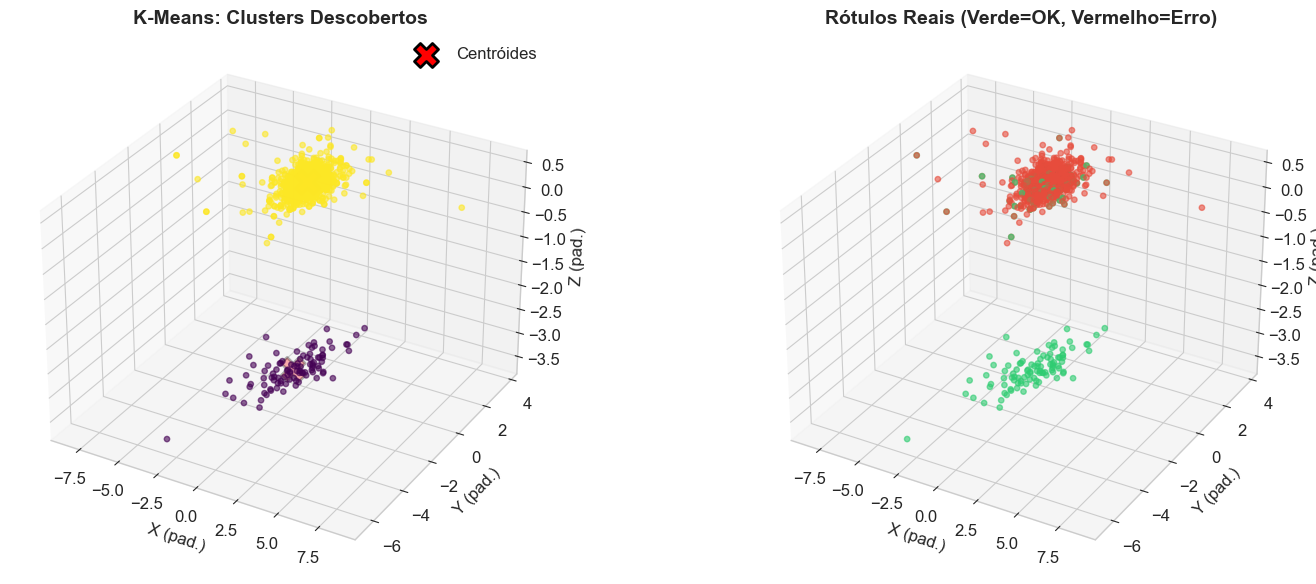


💡 Compare os dois gráficos!
   O K-Means conseguiu separar os dados de forma parecida com os rótulos reais?


In [48]:
# --- 4.2 K-Means com K=2 nos dados brutos ---
kmeans_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_raw.fit(X_raw_scaled)
labels_kmeans_raw = kmeans_raw.labels_

print("🔵 K-Means (K=2) nos dados brutos padronizados")
print(f"   Clusters encontrados: {np.unique(labels_kmeans_raw)}")
print(f"   Tamanho dos clusters:")
for cl in np.unique(labels_kmeans_raw):
    print(f"     Cluster {cl}: {np.sum(labels_kmeans_raw == cl)} pontos")

print(f"\n   Inércia (soma das distâncias ao centróide): {kmeans_raw.inertia_:.2f}")
print(f"   Centróides (no espaço padronizado):")
for i, c in enumerate(kmeans_raw.cluster_centers_):
    print(f"     Cluster {i}: X={c[0]:.3f}, Y={c[1]:.3f}, Z={c[2]:.3f}")

# --- Visualização 3D ---
fig = plt.figure(figsize=(16, 6))

# Plot 1: Clusters do K-Means
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X_raw_scaled[:, 0], X_raw_scaled[:, 1], X_raw_scaled[:, 2],
                       c=labels_kmeans_raw, cmap='viridis', s=15, alpha=0.6)
# Plotar centróides
centers = kmeans_raw.cluster_centers_
ax1.scatter(centers[:, 0], centers[:, 1], centers[:, 2], 
            c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centróides')
ax1.set_xlabel('X (pad.)')
ax1.set_ylabel('Y (pad.)')
ax1.set_zlabel('Z (pad.)')
ax1.set_title('K-Means: Clusters Descobertos', fontweight='bold')
ax1.legend()

# Plot 2: Rótulos reais (para comparação visual)
ax2 = fig.add_subplot(122, projection='3d')
colors_real = ['#2ecc71' if y == 'no' else '#e74c3c' for y in y_raw_text]
ax2.scatter(X_raw_scaled[:, 0], X_raw_scaled[:, 1], X_raw_scaled[:, 2],
            c=colors_real, s=15, alpha=0.6)
ax2.set_xlabel('X (pad.)')
ax2.set_ylabel('Y (pad.)')
ax2.set_zlabel('Z (pad.)')
ax2.set_title('Rótulos Reais (Verde=OK, Vermelho=Erro)', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Compare os dois gráficos!")
print("   O K-Means conseguiu separar os dados de forma parecida com os rótulos reais?")

### 4.3 Método do Cotovelo (Elbow Method)

Nós **chutamos** K=2. Mas como **escolher K sistematicamente?**

O **Método do Cotovelo** funciona assim:
1. Rode K-Means para K = 1, 2, 3, ..., 10
2. Para cada K, meça a **inércia** (soma das distâncias de cada ponto ao seu centróide)
3. Plote um gráfico de K vs. Inércia
4. Procure o "cotovelo" — o ponto onde **adicionar mais clusters para de trazer melhoria significativa**

> **💡 Analogia:** É como adicionar açúcar ao café. A primeira colher faz muita diferença, a segunda um pouco, a terceira quase nada. O "cotovelo" é onde você para de adicionar porque não vale mais a pena.

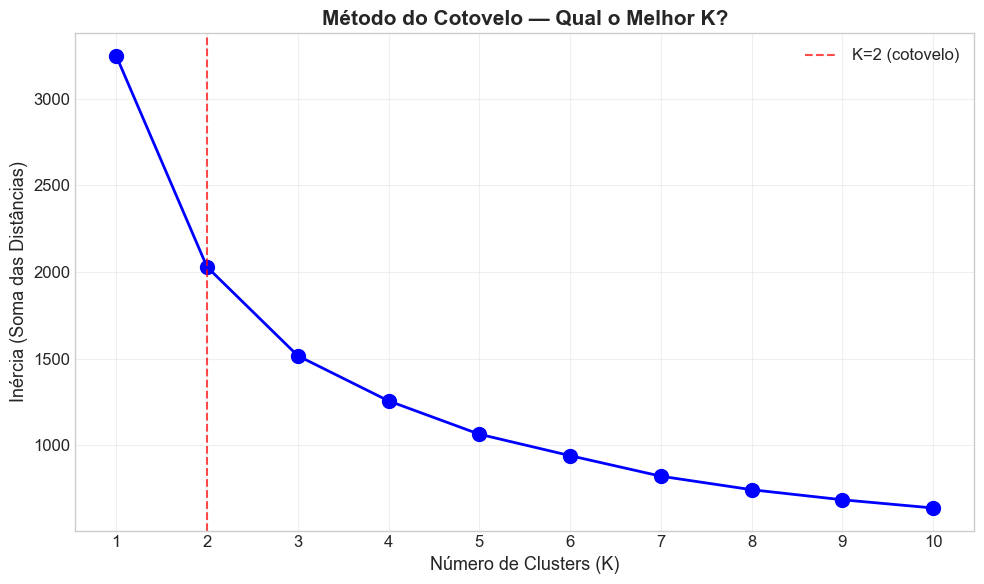

📊 Inércias por K:
   K= 1: Inércia =  3246.00 | Redução total:   0.0%
   K= 2: Inércia =  2028.68 | Redução total:  37.5%
   K= 3: Inércia =  1516.18 | Redução total:  53.3%
   K= 4: Inércia =  1255.80 | Redução total:  61.3%
   K= 5: Inércia =  1063.59 | Redução total:  67.2%
   K= 6: Inércia =   939.94 | Redução total:  71.0%
   K= 7: Inércia =   821.34 | Redução total:  74.7%
   K= 8: Inércia =   743.38 | Redução total:  77.1%
   K= 9: Inércia =   685.32 | Redução total:  78.9%
   K=10: Inércia =   637.97 | Redução total:  80.3%

💡 Interpretação:
   A inércia sempre diminui com mais clusters (cada ponto fica mais perto do centróide).
   O 'cotovelo' indica onde a redução marginal fica pequena — geralmente K=2 ou K=3.


In [49]:
# --- 4.3 Método do Cotovelo ---
K_range = range(1, 11)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_raw_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
ax.set_xlabel('Número de Clusters (K)', fontsize=13)
ax.set_ylabel('Inércia (Soma das Distâncias)', fontsize=13)
ax.set_title('Método do Cotovelo — Qual o Melhor K?', fontsize=15, fontweight='bold')
ax.set_xticks(list(K_range))

# Marcar o cotovelo sugerido
ax.axvline(x=2, color='red', linestyle='--', alpha=0.7, label='K=2 (cotovelo)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Inércias por K:")
for k, inertia in zip(K_range, inertias):
    reduction = ((inertias[0] - inertia) / inertias[0]) * 100 if k > 1 else 0
    print(f"   K={k:2d}: Inércia = {inertia:8.2f} | Redução total: {reduction:5.1f}%")

print("\n💡 Interpretação:")
print("   A inércia sempre diminui com mais clusters (cada ponto fica mais perto do centróide).")
print("   O 'cotovelo' indica onde a redução marginal fica pequena — geralmente K=2 ou K=3.")

### 4.4 Análise de Silhueta (Silhouette Analysis)

O Método do Cotovelo olha apenas a **inércia** (distância intra-cluster). A **Análise de Silhueta** é mais completa porque mede dois aspectos:

Para cada ponto $i$:
- $a(i)$ = distância média ao **próprio cluster** (coesão)
- $b(i)$ = distância média ao **cluster vizinho mais próximo** (separação)
- **Coeficiente de Silhueta:** $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$

O valor varia de **-1 a +1**:
| Valor | Significado |
|-------|------------|
| **+1** | Ponto bem dentro do seu cluster, longe dos outros |
| **0** | Ponto na fronteira entre dois clusters |
| **-1** | Ponto provavelmente no cluster errado |

> **💡 Regra prática:** Silhueta média > 0.5 é bom, > 0.7 é excelente.

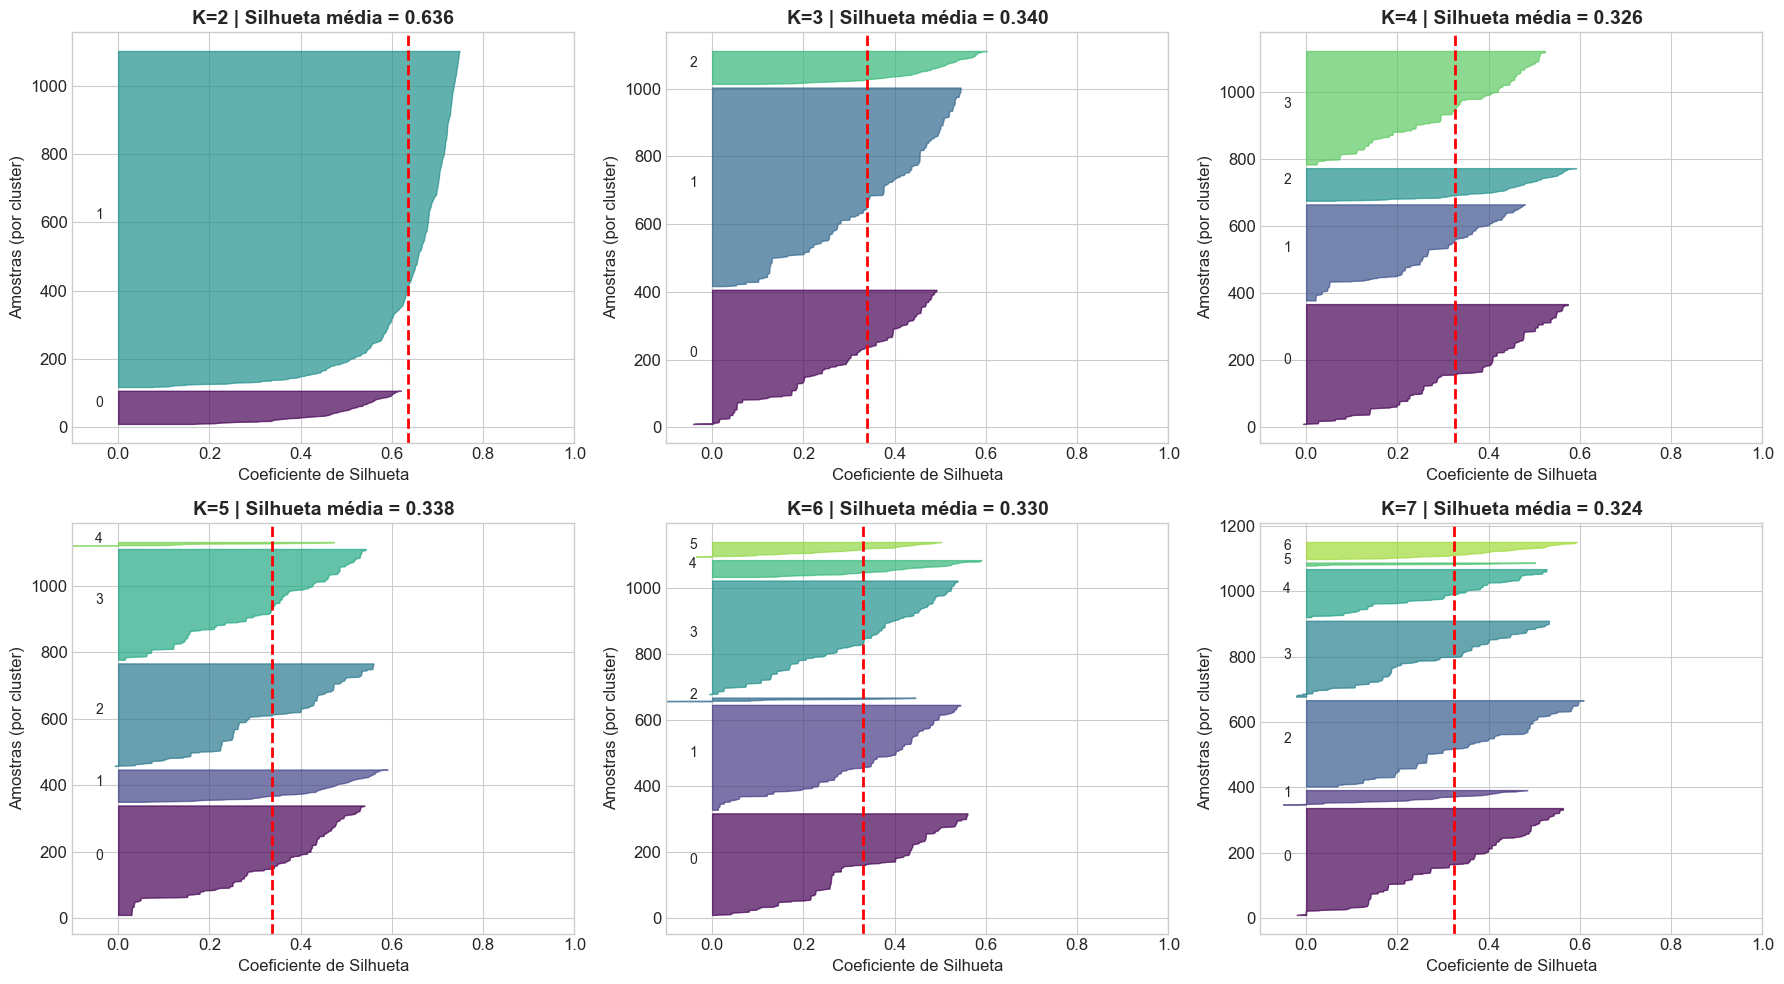

📊 Silhueta média por K:
   K=2: Silhueta = 0.6361 — ✅ Bom
   K=3: Silhueta = 0.3405 — ⚠️ Razoável
   K=4: Silhueta = 0.3263 — ⚠️ Razoável
   K=5: Silhueta = 0.3382 — ⚠️ Razoável
   K=6: Silhueta = 0.3300 — ⚠️ Razoável
   K=7: Silhueta = 0.3236 — ⚠️ Razoável

🏆 Melhor K pela silhueta: K=2 (silhueta = 0.6361)

💡 A linha vermelha tracejada é a silhueta média.
   Clusters 'bons' têm a maioria dos pontos à direita da linha.


In [50]:
# --- 4.4 Análise de Silhueta para diferentes K ---
K_sil_range = range(2, 8)
silhouette_avgs = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, k in enumerate(K_sil_range):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_raw_scaled)
    
    sil_avg = silhouette_score(X_raw_scaled, cluster_labels)
    silhouette_avgs.append(sil_avg)
    
    # Silhueta por amostra
    sample_scores = silhouette_samples(X_raw_scaled, cluster_labels)
    
    ax = axes[idx]
    y_lower = 10
    
    for i in range(k):
        ith_scores = sample_scores[cluster_labels == i]
        ith_scores.sort()
        
        size_cluster_i = ith_scores.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = plt.cm.viridis(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_scores, 
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=10)
        y_lower = y_upper + 10
    
    ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'K={k} | Silhueta média = {sil_avg:.3f}', fontweight='bold')
    ax.set_xlabel('Coeficiente de Silhueta')
    ax.set_ylabel('Amostras (por cluster)')
    ax.set_xlim([-0.1, 1])

plt.tight_layout()
plt.show()

# Resumo
print("📊 Silhueta média por K:")
for k, sil in zip(K_sil_range, silhouette_avgs):
    quality = "⭐ Excelente" if sil > 0.7 else "✅ Bom" if sil > 0.5 else "⚠️ Razoável" if sil > 0.25 else "❌ Fraco"
    print(f"   K={k}: Silhueta = {sil:.4f} — {quality}")

best_k = list(K_sil_range)[np.argmax(silhouette_avgs)]
print(f"\n🏆 Melhor K pela silhueta: K={best_k} (silhueta = {max(silhouette_avgs):.4f})")
print("\n💡 A linha vermelha tracejada é a silhueta média.")
print("   Clusters 'bons' têm a maioria dos pontos à direita da linha.")

### 4.5 Interpretação dos Clusters vs. Rótulos Reais

Agora vem a pergunta chave: **O K-Means, sem nunca ver os rótulos, conseguiu descobrir algo parecido com a verdade?**

Para responder, usamos o **Adjusted Rand Index (ARI)**:
- **ARI = 1.0** → Concordância perfeita (clusters = rótulos reais)
- **ARI = 0.0** → Concordância aleatória (como jogar moeda)
- **ARI < 0** → Pior que aleatório

> **⚠️ Cuidado:** Os números dos clusters (0, 1) podem estar "trocados" em relação aos rótulos (no, yes). O ARI lida com isso automaticamente.

📊 Adjusted Rand Index (ARI): 0.4029
   ✅ Bom! Há concordância significativa entre clusters e rótulos.

📋 Tabela Cruzada (Cluster × Rótulo Real):


Rótulo Real,no,yes,All
Cluster K-Means,,,
0,98,0,98
1,151,833,984
All,249,833,1082


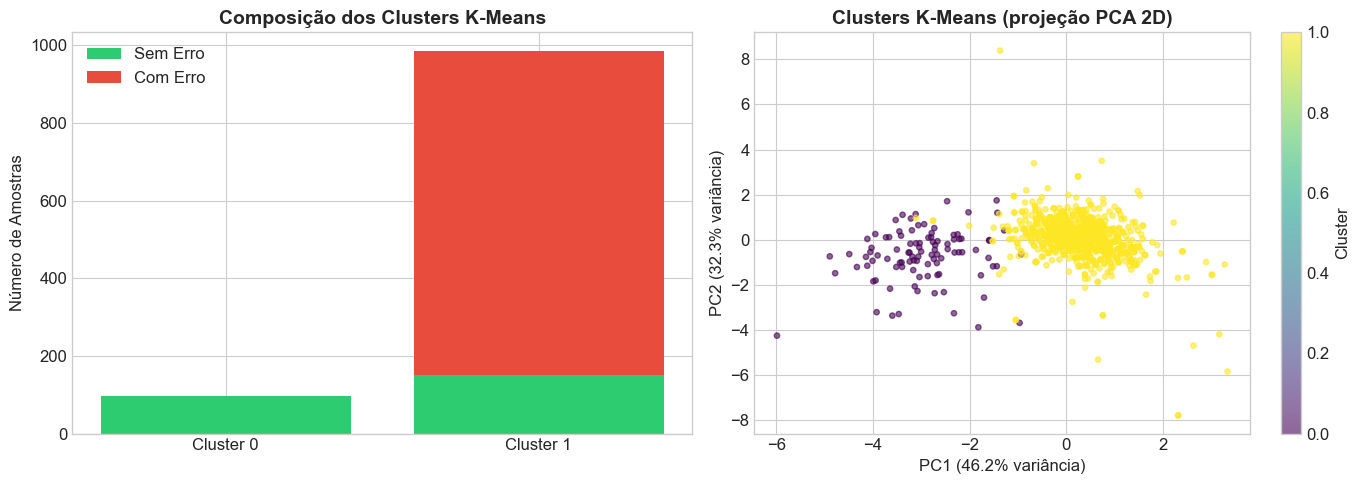


💡 Observações Importantes:
   1. Se um cluster tem maioria 'no' e outro maioria 'yes', o K-Means funcionou!
   2. Usamos PCA apenas para VISUALIZAR — reduzir 3D → 2D (prévia da Aula 8)
   3. Mesmo que o ARI não seja perfeito, é impressionante que o algoritmo
      consiga separar padrões SEM ter visto nenhum rótulo!


In [51]:
# --- 4.5 Comparação: Clusters K-Means vs. Rótulos Reais ---

# Converter rótulos reais para numérico: no=0, yes=1
y_raw_numeric = np.array([0 if y == 'no' else 1 for y in y_raw_text])

# Adjusted Rand Index
ari = adjusted_rand_score(y_raw_numeric, labels_kmeans_raw)
print(f"📊 Adjusted Rand Index (ARI): {ari:.4f}")

if ari > 0.7:
    print("   ⭐ Excelente! O K-Means descobriu uma estrutura muito próxima dos rótulos reais.")
elif ari > 0.4:
    print("   ✅ Bom! Há concordância significativa entre clusters e rótulos.")
elif ari > 0.1:
    print("   ⚠️ Moderado. Alguma concordância, mas os clusters não correspondem bem aos rótulos.")
else:
    print("   ❌ Fraco. Os clusters não correspondem aos rótulos — o que pode significar que")
    print("      os dados brutos (X, Y, Z) não separam bem as classes sem Feature Engineering!")

# Tabela cruzada: Cluster vs. Rótulo Real
print("\n📋 Tabela Cruzada (Cluster × Rótulo Real):")
ct = pd.crosstab(
    pd.Series(labels_kmeans_raw, name='Cluster K-Means'),
    pd.Series(y_raw_text, name='Rótulo Real'),
    margins=True
)
display(ct)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribuição dos rótulos reais dentro de cada cluster
for cl in np.unique(labels_kmeans_raw):
    mask = labels_kmeans_raw == cl
    labels_in_cluster = y_raw_text[mask]
    no_count = np.sum(labels_in_cluster == 'no')
    yes_count = np.sum(labels_in_cluster == 'yes')
    
    axes[0].bar(f'Cluster {cl}', no_count, color='#2ecc71', label='Sem Erro' if cl == 0 else '')
    axes[0].bar(f'Cluster {cl}', yes_count, bottom=no_count, color='#e74c3c', label='Com Erro' if cl == 0 else '')

axes[0].set_title('Composição dos Clusters K-Means', fontweight='bold')
axes[0].set_ylabel('Número de Amostras')
axes[0].legend()

# Plot 2: Visualização 2D com PCA
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_raw_scaled)

scatter = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_kmeans_raw, 
                          cmap='viridis', s=15, alpha=0.6)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variância)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variância)')
axes[1].set_title('Clusters K-Means (projeção PCA 2D)', fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

print("\n💡 Observações Importantes:")
print("   1. Se um cluster tem maioria 'no' e outro maioria 'yes', o K-Means funcionou!")
print("   2. Usamos PCA apenas para VISUALIZAR — reduzir 3D → 2D (prévia da Aula 8)")
print("   3. Mesmo que o ARI não seja perfeito, é impressionante que o algoritmo")
print("      consiga separar padrões SEM ter visto nenhum rótulo!")

---

## 5. Parte B — DBSCAN: Clustering Baseado em Densidade

### 5.1 Como o DBSCAN Funciona?

O **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) funciona de forma completamente diferente do K-Means:

#### Conceitos Fundamentais:

| Conceito | Definição | No nosso caso |
|----------|-----------|---------------|
| **ε (eps)** | Raio de vizinhança | "Quão perto dois pontos precisam estar para serem vizinhos" |
| **min_samples** | Mínimo de vizinhos para ser "core" | "Quantos vizinhos para ser uma região densa" |
| **Core point** | Ponto com ≥ min_samples vizinhos em raio ε | Centro de um cluster |
| **Border point** | Vizinho de um core, mas sem vizinhos suficientes | Borda do cluster |
| **Noise (-1)** | Não é core nem border | **ANOMALIA / OUTLIER!** |

#### Algoritmo Passo a Passo:
1. Para cada ponto, conta quantos vizinhos estão dentro do raio ε
2. Se tem ≥ min_samples vizinhos → é **core point**, inicia um cluster
3. Expande o cluster: todos os vizinhos do core são adicionados; se algum vizinho também é core, expande novamente
4. Pontos que não são core nem border de ninguém → **ruído (noise)**

### 🔑 Vantagens do DBSCAN sobre K-Means

| Aspecto | K-Means | DBSCAN |
|---------|---------|--------|
| Número de clusters | Precisa definir K | **Descobre automaticamente** |
| Forma dos clusters | Esférica | **Qualquer forma** |
| Outliers | Não detecta | **Detecta como ruído (-1)** |
| Sensibilidade a ruído | Alta (outlier puxa centróide) | **Baixa (outlier vira -1)** |
| Tamanho dos clusters | Similar | **Pode variar** |

> **💡 Quando usar DBSCAN?** Quando você quer **detectar anomalias** ou quando os clusters têm **formas irregulares**. É exatamente o nosso caso na fábrica — queremos saber quando algo "estranho" aconteceu!

In [52]:
# --- 5.2 DBSCAN nos dados brutos ---

# Testar diferentes combinações de eps e min_samples
eps_values = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]
results_dbscan = []

print("📊 Testando diferentes parâmetros do DBSCAN:\n")
print(f"{'eps':>6s} | {'Clusters':>8s} | {'Outliers':>8s} | {'% Outliers':>10s} | {'Silhueta':>10s}")
print("-" * 55)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels_db = db.fit_predict(X_raw_scaled)
    
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_outliers = np.sum(labels_db == -1)
    pct_outliers = n_outliers / len(labels_db) * 100
    
    # Silhueta (apenas se houver pelo menos 2 clusters e nem todos forem outliers)
    non_noise_mask = labels_db != -1
    if n_clusters >= 2 and np.sum(non_noise_mask) > n_clusters:
        sil = silhouette_score(X_raw_scaled[non_noise_mask], labels_db[non_noise_mask])
    else:
        sil = float('nan')
    
    results_dbscan.append({
        'eps': eps, 'n_clusters': n_clusters, 'n_outliers': n_outliers,
        'pct_outliers': pct_outliers, 'silhouette': sil
    })
    
    print(f"{eps:6.1f} | {n_clusters:8d} | {n_outliers:8d} | {pct_outliers:9.1f}% | {sil:10.4f}")

print("\n💡 Observações:")
print("   • eps muito pequeno → muitos outliers (quase tudo é 'estranho')")
print("   • eps muito grande → 1 cluster gigante (tudo é 'normal')")
print("   • Precisamos do equilíbrio: poucos clusters, poucos outliers REAIS")

📊 Testando diferentes parâmetros do DBSCAN:

   eps | Clusters | Outliers | % Outliers |   Silhueta
-------------------------------------------------------
   0.3 |        4 |      131 |      12.1% |     0.6536
   0.5 |        3 |       69 |       6.4% |     0.6382
   0.8 |        2 |       37 |       3.4% |     0.6614
   1.0 |        2 |       25 |       2.3% |     0.6548
   1.5 |        2 |       10 |       0.9% |     0.6483
   2.0 |        2 |        8 |       0.7% |     0.6459

💡 Observações:
   • eps muito pequeno → muitos outliers (quase tudo é 'estranho')
   • eps muito grande → 1 cluster gigante (tudo é 'normal')
   • Precisamos do equilíbrio: poucos clusters, poucos outliers REAIS


🔍 DBSCAN (eps=0.8, min_samples=5):
   Clusters encontrados: 2
   Outliers detectados:  37 (3.4%)


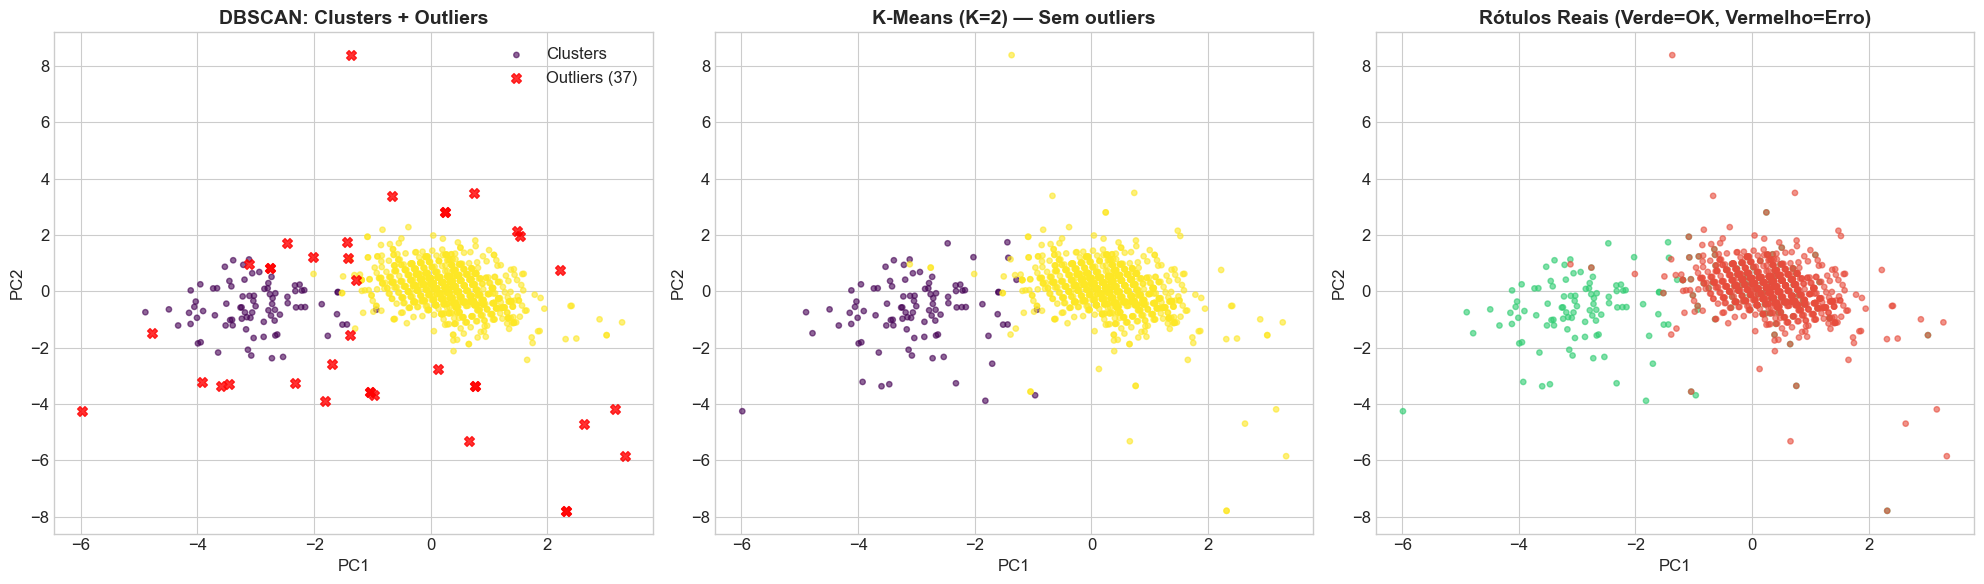


📊 ARI do DBSCAN (excluindo outliers): 0.3829

💡 Comparação K-Means vs. DBSCAN:
   • K-Means força TODOS os pontos num cluster — inclusive os estranhos
   • DBSCAN identifica pontos isolados como OUTLIERS (X vermelhos)
   • Na fábrica, esses outliers seriam candidatos a alerta de defeito!


In [53]:
# --- 5.2 Visualização do DBSCAN com melhor eps ---

# Escolher eps=0.8 como bom ponto de partida (ajustar se necessário)
dbscan_best = DBSCAN(eps=0.8, min_samples=5)
labels_dbscan_raw = dbscan_best.fit_predict(X_raw_scaled)

n_clusters_db = len(set(labels_dbscan_raw)) - (1 if -1 in labels_dbscan_raw else 0)
n_outliers_db = np.sum(labels_dbscan_raw == -1)

print(f"🔍 DBSCAN (eps=0.8, min_samples=5):")
print(f"   Clusters encontrados: {n_clusters_db}")
print(f"   Outliers detectados:  {n_outliers_db} ({n_outliers_db/len(labels_dbscan_raw)*100:.1f}%)")

# Usar a projeção PCA 2D já calculada
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: DBSCAN clusters
non_noise = labels_dbscan_raw != -1
axes[0].scatter(X_pca_2d[non_noise, 0], X_pca_2d[non_noise, 1], 
                c=labels_dbscan_raw[non_noise], cmap='viridis', s=15, alpha=0.6, label='Clusters')
axes[0].scatter(X_pca_2d[~non_noise, 0], X_pca_2d[~non_noise, 1], 
                c='red', marker='X', s=50, alpha=0.8, label=f'Outliers ({n_outliers_db})')
axes[0].set_title('DBSCAN: Clusters + Outliers', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Plot 2: K-Means (para comparar)
axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_kmeans_raw, 
                cmap='viridis', s=15, alpha=0.6)
axes[1].set_title('K-Means (K=2) — Sem outliers', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Plot 3: Rótulos reais
colors_real = ['#2ecc71' if y == 'no' else '#e74c3c' for y in y_raw_text]
axes[2].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=colors_real, s=15, alpha=0.6)
axes[2].set_title('Rótulos Reais (Verde=OK, Vermelho=Erro)', fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# ARI do DBSCAN (excluindo outliers)
if n_clusters_db >= 1:
    ari_dbscan = adjusted_rand_score(y_raw_numeric[non_noise], labels_dbscan_raw[non_noise])
    print(f"\n📊 ARI do DBSCAN (excluindo outliers): {ari_dbscan:.4f}")

print("\n💡 Comparação K-Means vs. DBSCAN:")
print("   • K-Means força TODOS os pontos num cluster — inclusive os estranhos")
print("   • DBSCAN identifica pontos isolados como OUTLIERS (X vermelhos)")
print("   • Na fábrica, esses outliers seriam candidatos a alerta de defeito!")

---

## 6. Parte C — Clustering Hierárquico (Dendrograma)

### 🌳 O Que É Clustering Hierárquico?

O clustering hierárquico cria uma **árvore de agrupamentos** (dendrograma) que mostra como os dados se organizam em diferentes níveis de granularidade:

1. **Aglomerativo (bottom-up):** Começa com cada ponto como cluster individual, depois vai juntando os mais próximos
2. **Divisivo (top-down):** Começa com tudo junto e vai dividindo

### 🔑 Métodos de Ligação (Linkage)

| Método | Como mede distância entre clusters | Quando usar |
|--------|-------------------------------------|-------------|
| **Ward** | Minimiza a variância intra-cluster | Clusters esféricos (parecido com K-Means) |
| **Complete** | Máxima distância entre pontos | Clusters compactos |
| **Average** | Média das distâncias | Equilíbrio geral |
| **Single** | Mínima distância entre pontos | Clusters com formas alongadas |

### 💡 Por que usar o Dendrograma?

O dendrograma é poderoso porque **não precisa que você defina K antes**. Você pode:
1. Plotar o dendrograma completo
2. Cortar em diferentes alturas para obter diferentes números de clusters
3. Visualizar a hierarquia natural dos dados

> **Analogia:** É como uma árvore genealógica dos dados — mostra quais pontos são "parentes próximos" e quais são "primos distantes".

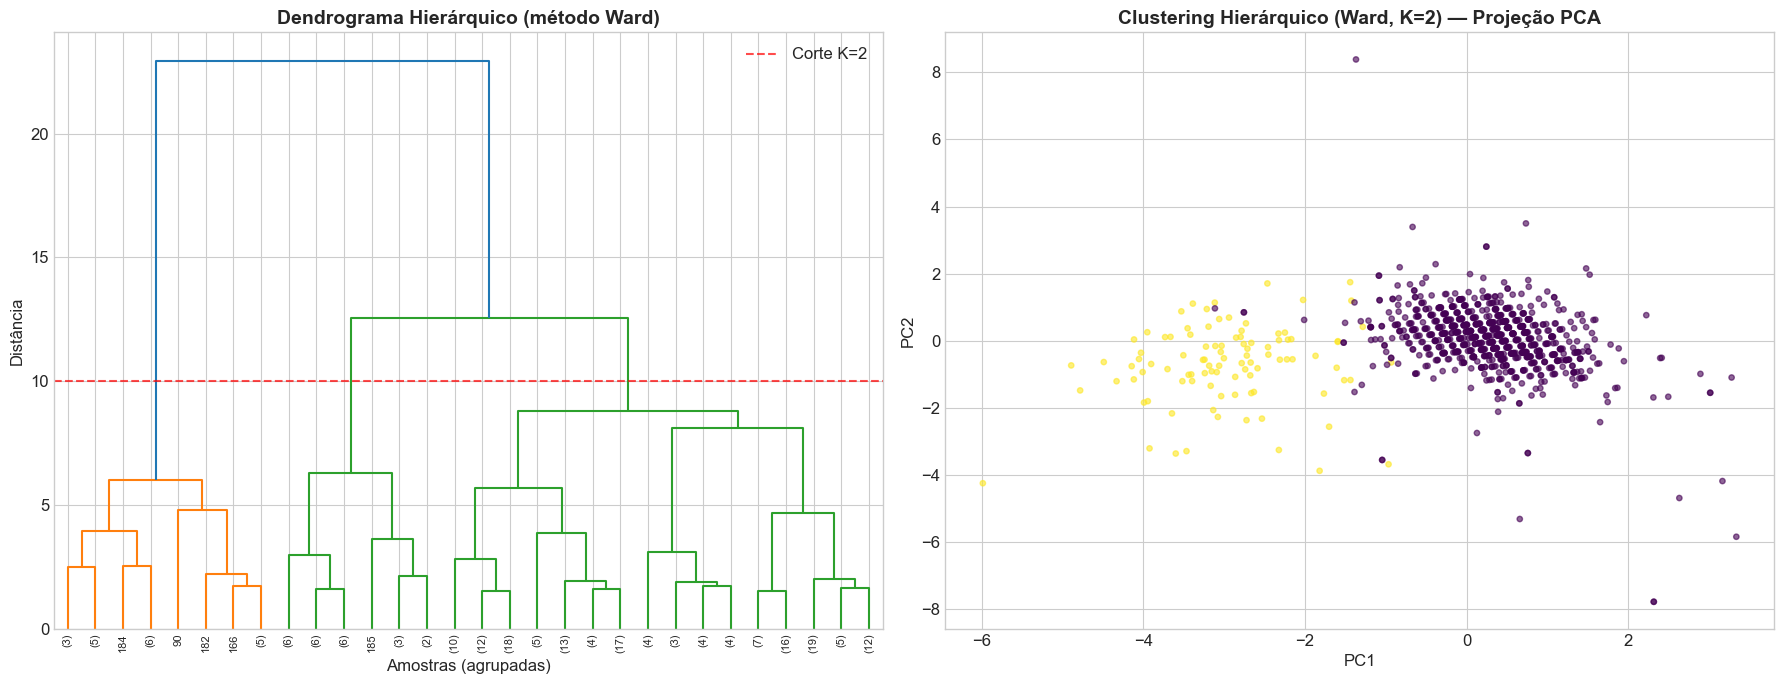

📊 Clustering Hierárquico (Ward, K=2):
   ARI vs. rótulos reais: 0.4029
   Silhueta média: 0.6361
   Tamanhos dos clusters: [984, 98]

💡 O dendrograma mostra a 'história' do agrupamento:
   • Na base, cada ponto é seu próprio cluster
   • Subindo, os mais similares vão se fundindo
   • A linha vermelha tracejada mostra onde 'cortamos' para obter 2 clusters
   • Grandes saltos verticais indicam clusters bem separados


In [54]:
# --- 6. Clustering Hierárquico ---

# Para o dendrograma, usamos uma amostra (1082 pontos ficaria ilegível)
np.random.seed(42)
sample_idx = np.random.choice(len(X_raw_scaled), size=200, replace=False)
X_sample = X_raw_scaled[sample_idx]
y_sample = y_raw_text[sample_idx]

# Calcular a linkage (hierarquia)
Z_ward = linkage(X_sample, method='ward')

# Dendrograma
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Dendrograma completo
dendrogram(Z_ward, ax=axes[0], truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8, show_leaf_counts=True)
axes[0].set_title('Dendrograma Hierárquico (método Ward)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Amostras (agrupadas)')
axes[0].set_ylabel('Distância')
axes[0].axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Corte K=2')
axes[0].legend(fontsize=12)

# Plot 2: Resultado do corte com K=2
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_hier = agg.fit_predict(X_raw_scaled)

axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_hier, cmap='viridis', s=15, alpha=0.6)
axes[1].set_title('Clustering Hierárquico (Ward, K=2) — Projeção PCA', fontweight='bold', fontsize=14)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# ARI
ari_hier = adjusted_rand_score(y_raw_numeric, labels_hier)
sil_hier = silhouette_score(X_raw_scaled, labels_hier)

print(f"📊 Clustering Hierárquico (Ward, K=2):")
print(f"   ARI vs. rótulos reais: {ari_hier:.4f}")
print(f"   Silhueta média: {sil_hier:.4f}")
print(f"   Tamanhos dos clusters: {np.bincount(labels_hier).tolist()}")

print("\n💡 O dendrograma mostra a 'história' do agrupamento:")
print("   • Na base, cada ponto é seu próprio cluster")
print("   • Subindo, os mais similares vão se fundindo")
print("   • A linha vermelha tracejada mostra onde 'cortamos' para obter 2 clusters")
print("   • Grandes saltos verticais indicam clusters bem separados")

---

## 7. Parte D — Clustering nas Features Engenheiradas (27 Features)

### 7.1 Por Que Usar Features Engenheiradas?

Até agora trabalhamos com os **dados brutos (3 features: X, Y, Z)**. Mas na Aula 5 criamos **27 features** ricas que capturam:
- **Temporais:** RMS, média, desvio padrão, máximo, mínimo, kurtosis, skewness (× 3 eixos = 21)
- **Frequência:** FFT mean, FFT max (× 3 eixos = 6)

### 🤔 Qual a Diferença Prática?

| Aspecto | Dados Brutos (3 features) | Features Engenheiradas (27 features) |
|---------|---------------------------|--------------------------------------|
| **Nº amostras** | 1082 leituras individuais | 32 janelas (resumos de ~34 leituras cada) |
| **Nº features** | 3 (X, Y, Z) | 27 (estatísticas + frequência) |
| **Informação** | Uma leitura instantânea | Resumo estatístico de uma janela temporal |
| **Visualização** | Fácil (3D) | Difícil (27D → precisa de PCA/UMAP!) |
| **Para ML** | Limitado | Muito mais rico — é o que usamos na Aula 6 |

> **💡 Na aula anterior (Aula 6, supervisionado)**, obtivemos excelentes resultados com as features engenheiradas. Agora veremos se o clustering **não supervisionado** também se beneficia delas.

> **⚠️ Atenção:** Com 27 features, **não podemos visualizar diretamente**. Usaremos PCA para projetar em 2D — isto é apenas uma prévia da **Aula 8 (Redução de Dimensionalidade)** onde estudaremos PCA e UMAP em profundidade.

📐 Dataset de features engenheiradas:
   Shape: (32, 27) (amostras × features)
   Features: ['X_rms', 'X_mean', 'X_std', 'X_max', 'X_min']... (27 total)
   Distribuição real: no=7, yes=25

🔵 K-Means (K=2) nas features engenheiradas:
   Silhueta média: 0.4769
   ARI vs. rótulos reais: 0.4417
   Tamanhos: Cluster 0=29, Cluster 1=3


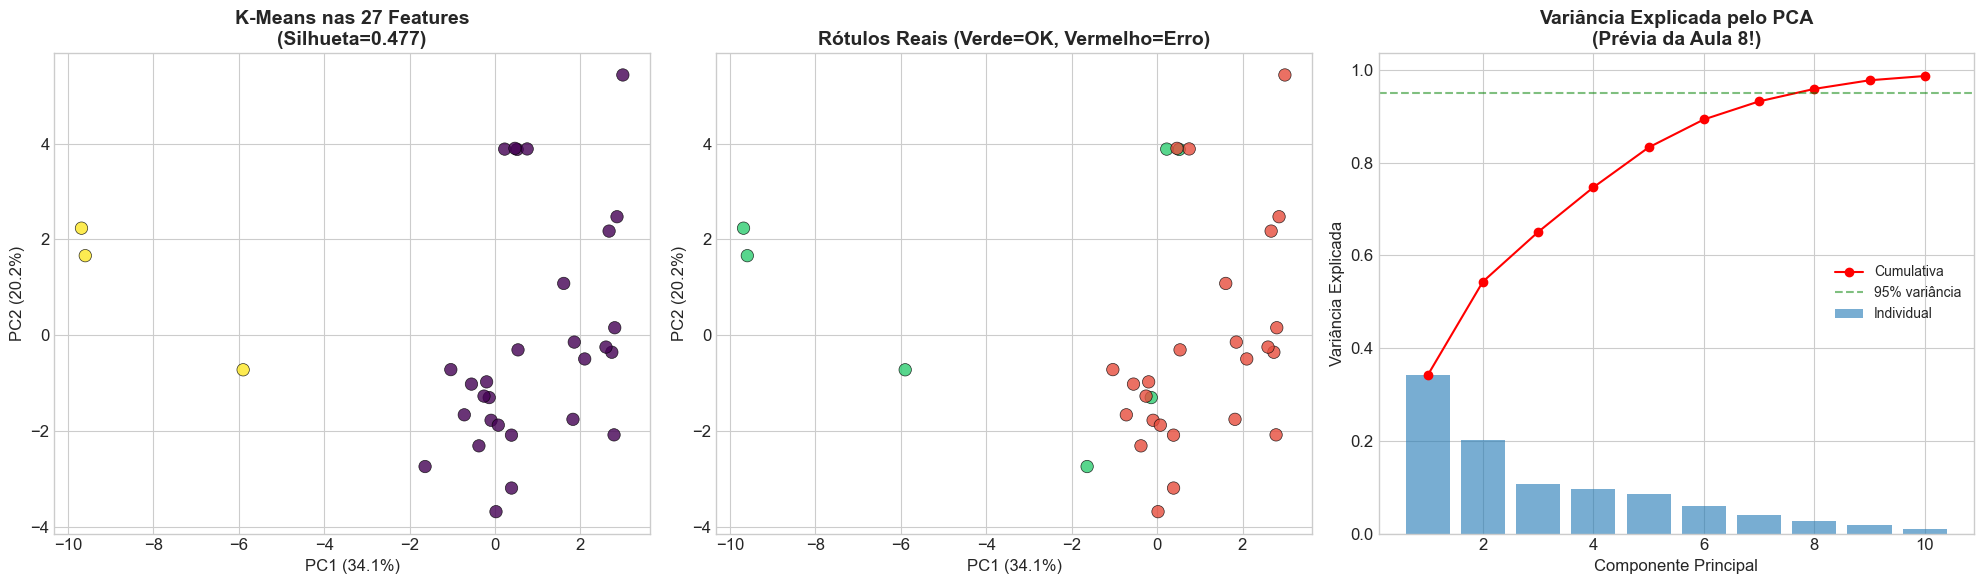


📊 PCA: Reduzimos 27D → 2D, mantendo 54.3% da variância
   Para 95% da variância, precisaríamos de ~8 componentes

💡 Este gráfico de variância será o tema central da Aula 8!
   Lá aprenderemos como escolher o número ideal de componentes.


In [55]:
# --- 7.2 Preparação e K-Means nas Features Engenheiradas ---

# Separar features e rótulos
feature_cols = [c for c in df_feat.columns if c != 'label']
X_feat = df_feat[feature_cols].values
y_feat_text = df_feat['label'].values
y_feat_numeric = np.array([0 if y == 'no' else 1 for y in y_feat_text])

# Padronizar
scaler_feat = StandardScaler()
X_feat_scaled = scaler_feat.fit_transform(X_feat)

print(f"📐 Dataset de features engenheiradas:")
print(f"   Shape: {X_feat_scaled.shape} (amostras × features)")
print(f"   Features: {feature_cols[:5]}... ({len(feature_cols)} total)")
print(f"   Distribuição real: no={np.sum(y_feat_numeric==0)}, yes={np.sum(y_feat_numeric==1)}")

# K-Means com K=2
kmeans_feat = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans_feat = kmeans_feat.fit_predict(X_feat_scaled)

# Silhueta
sil_feat = silhouette_score(X_feat_scaled, labels_kmeans_feat)
ari_feat = adjusted_rand_score(y_feat_numeric, labels_kmeans_feat)

print(f"\n🔵 K-Means (K=2) nas features engenheiradas:")
print(f"   Silhueta média: {sil_feat:.4f}")
print(f"   ARI vs. rótulos reais: {ari_feat:.4f}")
print(f"   Tamanhos: Cluster 0={np.sum(labels_kmeans_feat==0)}, Cluster 1={np.sum(labels_kmeans_feat==1)}")

# --- Visualização com PCA 2D ---
pca_feat = PCA(n_components=2)
X_feat_pca = pca_feat.fit_transform(X_feat_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Clusters K-Means
scatter1 = axes[0].scatter(X_feat_pca[:, 0], X_feat_pca[:, 1], c=labels_kmeans_feat, 
                           cmap='viridis', s=80, alpha=0.8, edgecolors='black', linewidths=0.5)
axes[0].set_title(f'K-Means nas 27 Features\n(Silhueta={sil_feat:.3f})', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_feat.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_feat.explained_variance_ratio_[1]:.1%})')

# Plot 2: Rótulos reais
colors_feat_real = ['#2ecc71' if y == 'no' else '#e74c3c' for y in y_feat_text]
axes[1].scatter(X_feat_pca[:, 0], X_feat_pca[:, 1], c=colors_feat_real, 
                s=80, alpha=0.8, edgecolors='black', linewidths=0.5)
axes[1].set_title('Rótulos Reais (Verde=OK, Vermelho=Erro)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_feat.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_feat.explained_variance_ratio_[1]:.1%})')

# Plot 3: Variância explicada pelo PCA
n_comp = min(10, X_feat_scaled.shape[1])
pca_full = PCA(n_components=n_comp)
pca_full.fit(X_feat_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

axes[2].bar(range(1, n_comp+1), pca_full.explained_variance_ratio_, alpha=0.6, label='Individual')
axes[2].plot(range(1, n_comp+1), cumvar, 'ro-', label='Cumulativa')
axes[2].axhline(y=0.95, color='green', linestyle='--', alpha=0.5, label='95% variância')
axes[2].set_xlabel('Componente Principal')
axes[2].set_ylabel('Variância Explicada')
axes[2].set_title('Variância Explicada pelo PCA\n(Prévia da Aula 8!)', fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 PCA: Reduzimos 27D → 2D, mantendo {pca_feat.explained_variance_ratio_.sum():.1%} da variância")
print(f"   Para 95% da variância, precisaríamos de ~{np.argmax(cumvar >= 0.95) + 1} componentes")
print("\n💡 Este gráfico de variância será o tema central da Aula 8!")
print("   Lá aprenderemos como escolher o número ideal de componentes.")

📊 Testando DBSCAN nas 27 features engenheiradas:

   eps | Clusters | Outliers | % Outliers |   Silhueta
-------------------------------------------------------
   0.5 |        0 |       32 |     100.0% |        nan
   1.0 |        1 |       28 |      87.5% |        nan
   1.5 |        3 |       22 |      68.8% |     0.7607
   2.0 |        4 |       17 |      53.1% |     0.5640
   3.0 |        2 |        9 |      28.1% |     0.4708
   4.0 |        2 |        7 |      21.9% |     0.4046

🏆 Melhor eps=1.5 (Silhueta=0.7607, Clusters=3, Outliers=22)


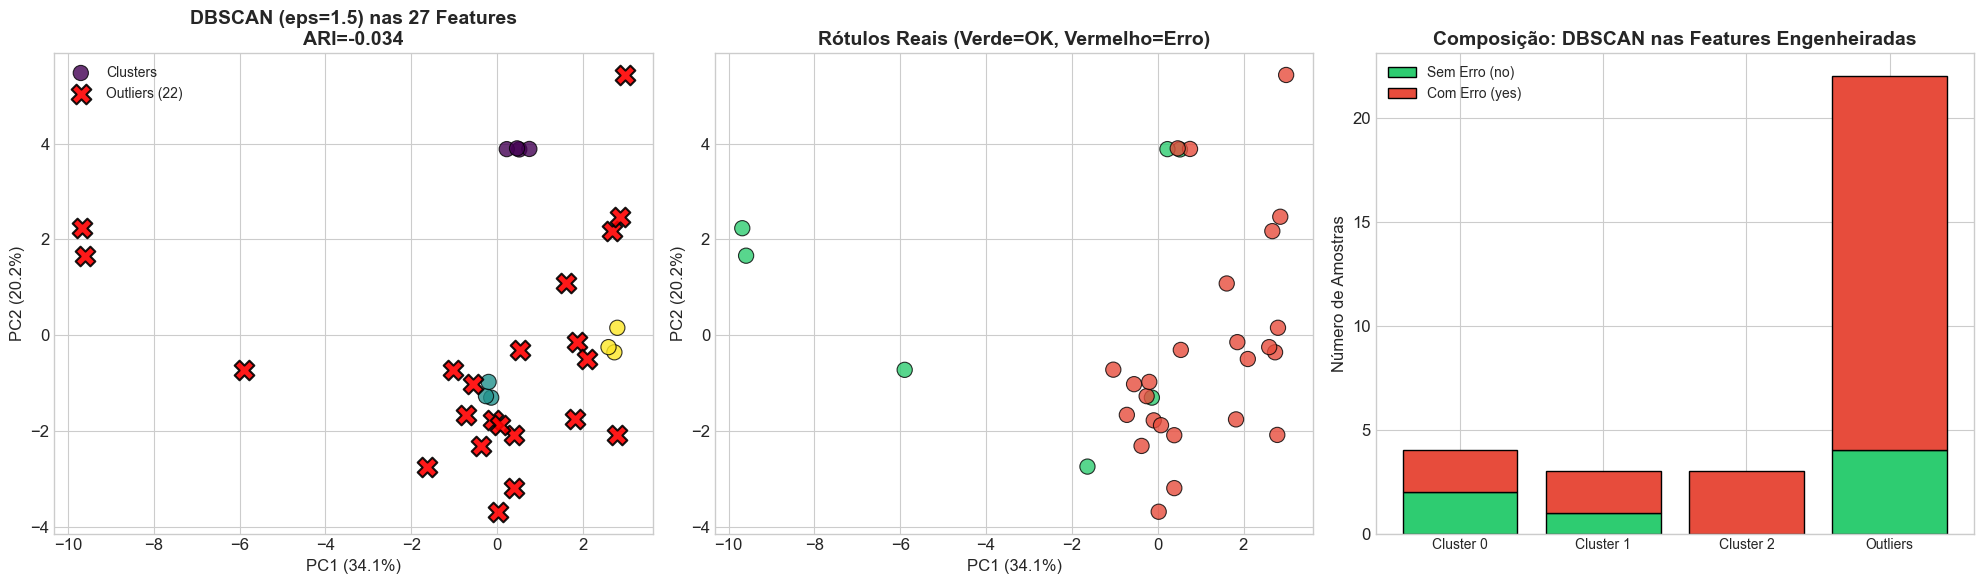


📊 Resumo DBSCAN nas Features Engenheiradas (eps=1.5):
   Clusters encontrados: 3
   Outliers detectados:  22 (68.8%)
   ARI vs. rótulos reais (excl. outliers): -0.0345
   Silhueta: 0.7607

💡 DBSCAN nas features engenheiradas captura padrões mais ricos que nos dados brutos,
   pois cada ponto representa uma JANELA temporal com 27 estatísticas.
   Outliers aqui indicam janelas com comportamento completamente atípico!


In [72]:
# --- 7.3 DBSCAN nas Features Engenheiradas ---

# Testar diferentes parâmetros
eps_values_feat = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
results_dbscan_feat = []

print("📊 Testando DBSCAN nas 27 features engenheiradas:\n")
print(f"{'eps':>6s} | {'Clusters':>8s} | {'Outliers':>8s} | {'% Outliers':>10s} | {'Silhueta':>10s}")
print("-" * 55)

for eps_f in eps_values_feat:
    db_f = DBSCAN(eps=eps_f, min_samples=3)
    labels_db_f = db_f.fit_predict(X_feat_scaled)
    
    n_clusters_f = len(set(labels_db_f)) - (1 if -1 in labels_db_f else 0)
    n_outliers_f = np.sum(labels_db_f == -1)
    pct_outliers_f = n_outliers_f / len(labels_db_f) * 100
    
    non_noise_f = labels_db_f != -1
    if n_clusters_f >= 2 and np.sum(non_noise_f) > n_clusters_f:
        sil_f = silhouette_score(X_feat_scaled[non_noise_f], labels_db_f[non_noise_f])
    else:
        sil_f = float('nan')
    
    results_dbscan_feat.append({
        'eps': eps_f, 'n_clusters': n_clusters_f, 'n_outliers': n_outliers_f,
        'pct_outliers': pct_outliers_f, 'silhouette': sil_f, 'labels': labels_db_f
    })
    print(f"{eps_f:6.1f} | {n_clusters_f:8d} | {n_outliers_f:8d} | {pct_outliers_f:9.1f}% | {sil_f:10.4f}")

# Escolher o melhor eps (maior silhueta com clusters razoáveis)
valid = [r for r in results_dbscan_feat if r['n_clusters'] >= 2 and not np.isnan(r['silhouette'])]
best_result = max(valid, key=lambda r: r['silhouette']) if valid else results_dbscan_feat[2]
labels_dbscan_feat = best_result['labels']
best_eps_feat = best_result['eps']

print(f"\n🏆 Melhor eps={best_eps_feat} (Silhueta={best_result['silhouette']:.4f}, "
      f"Clusters={best_result['n_clusters']}, Outliers={best_result['n_outliers']})")

# Visualização com PCA 2D
non_noise_feat = labels_dbscan_feat != -1
n_outliers_best = np.sum(~non_noise_feat)

ari_dbscan_feat = adjusted_rand_score(y_feat_numeric[non_noise_feat], 
                                       labels_dbscan_feat[non_noise_feat]) if non_noise_feat.sum() > 0 else float('nan')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: DBSCAN clusters nas features (projeção PCA)
if non_noise_feat.any():
    scatter_db = axes[0].scatter(X_feat_pca[non_noise_feat, 0], X_feat_pca[non_noise_feat, 1],
                                 c=labels_dbscan_feat[non_noise_feat], cmap='viridis',
                                 s=120, alpha=0.8, edgecolors='black', linewidths=0.8,
                                 label='Clusters')
axes[0].scatter(X_feat_pca[~non_noise_feat, 0], X_feat_pca[~non_noise_feat, 1],
                c='red', marker='X', s=200, alpha=0.9,
                edgecolors='black', linewidths=1.5, label=f'Outliers ({n_outliers_best})', zorder=5)
axes[0].set_title(f'DBSCAN (eps={best_eps_feat}) nas 27 Features\n'
                  f'ARI={ari_dbscan_feat:.3f}', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_feat.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_feat.explained_variance_ratio_[1]:.1%})')
axes[0].legend(fontsize=10)

# Plot 2: Rótulos reais
colors_feat_real = ['#2ecc71' if y == 'no' else '#e74c3c' for y in y_feat_text]
axes[1].scatter(X_feat_pca[:, 0], X_feat_pca[:, 1], c=colors_feat_real,
                s=120, alpha=0.8, edgecolors='black', linewidths=0.8)
axes[1].set_title('Rótulos Reais (Verde=OK, Vermelho=Erro)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_feat.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_feat.explained_variance_ratio_[1]:.1%})')

# Plot 3: K-Means vs DBSCAN — composição de classes por cluster
cluster_ids = sorted([c for c in np.unique(labels_dbscan_feat) if c != -1])
bar_width = 0.35
x_pos = np.arange(len(cluster_ids) + 1)  # +1 para outliers

no_counts, yes_counts = [], []
cluster_labels_plot = [f'Cluster {c}' for c in cluster_ids] + ['Outliers']

for c in cluster_ids:
    mask_c = labels_dbscan_feat == c
    no_counts.append(np.sum(y_feat_text[mask_c] == 'no'))
    yes_counts.append(np.sum(y_feat_text[mask_c] == 'yes'))

# Outliers
no_counts.append(np.sum(y_feat_text[~non_noise_feat] == 'no'))
yes_counts.append(np.sum(y_feat_text[~non_noise_feat] == 'yes'))

axes[2].bar(x_pos, no_counts, label='Sem Erro (no)', color='#2ecc71', edgecolor='black')
axes[2].bar(x_pos, yes_counts, bottom=no_counts, label='Com Erro (yes)', color='#e74c3c', edgecolor='black')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(cluster_labels_plot, fontsize=10)
axes[2].set_title('Composição: DBSCAN nas Features Engenheiradas', fontweight='bold')
axes[2].set_ylabel('Número de Amostras')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 Resumo DBSCAN nas Features Engenheiradas (eps={best_eps_feat}):")
print(f"   Clusters encontrados: {best_result['n_clusters']}")
print(f"   Outliers detectados:  {n_outliers_best} ({n_outliers_best/len(labels_dbscan_feat)*100:.1f}%)")
print(f"   ARI vs. rótulos reais (excl. outliers): {ari_dbscan_feat:.4f}")
print(f"   Silhueta: {best_result['silhouette']:.4f}")
print("\n💡 DBSCAN nas features engenheiradas captura padrões mais ricos que nos dados brutos,")
print("   pois cada ponto representa uma JANELA temporal com 27 estatísticas.")
print("   Outliers aqui indicam janelas com comportamento completamente atípico!")

---

## 8. Comparação: Supervisionado vs. Não Supervisionado

### 🏁 Visão Geral dos Resultados

Vamos consolidar tudo que fizemos e comparar com os resultados da Aula 6 (supervisionado):

| Critério | Supervisionado (Aula 6) | Não Supervisionado (Aula 7) |
|----------|------------------------|----------------------------|
| **Precisa de rótulos?** | ✅ Sim | ❌ Não |
| **O que precisa definir?** | Algoritmo + hiperparâmetros | Algoritmo + hiperparâmetros + K |
| **Métricas** | Acurácia, F1, Recall, Precision | Silhueta, ARI (se tiver rótulos para validar) |
| **Detecta anomalias?** | Só se treinado para isso | ✅ DBSCAN faz nativamente |
| **Detecta erros novos?** | ❌ Só os tipos que viu no treino | ✅ Qualquer ponto "estranho" |
| **Custo de dados** | Alto (precisa rotular) | Baixo (dados brutos bastam) |
| **Precisão** | Geralmente maior | Geralmente menor |

### 🤔 Quando Usar Cada Um?

- **Supervisionado:** Quando temos **muitos dados rotulados** e queremos **classificar com alta precisão** tipos conhecidos de defeito
- **Não Supervisionado:** Quando **não temos rótulos**, queremos **descobrir padrões desconhecidos** ou **detectar anomalias inéditas**
- **Combinação (Ideal):** Usar não supervisionado para **explorar e detectar anomalias**, depois rodar supervisionado para **classificar com precisão** os defeitos já conhecidos

In [63]:
# --- 8. Tabela Comparativa Final ---

print("=" * 70)
print("📊 COMPARAÇÃO DOS MÉTODOS NÃO SUPERVISIONADOS")
print("=" * 70)

comparison_data = {
    'Algoritmo': ['K-Means (raw, K=2)', 'DBSCAN (raw)', 'Hierárquico (raw, K=2)', 
                  'K-Means (features, K=2)'],
    'Dataset': ['3 features brutas', '3 features brutas', '3 features brutas', 
                '27 features eng.'],
    'ARI': [
        adjusted_rand_score(y_raw_numeric, labels_kmeans_raw),
        adjusted_rand_score(y_raw_numeric[labels_dbscan_raw != -1], 
                            labels_dbscan_raw[labels_dbscan_raw != -1]) if np.sum(labels_dbscan_raw != -1) > 0 else float('nan'),
        adjusted_rand_score(y_raw_numeric, labels_hier),
        adjusted_rand_score(y_feat_numeric, labels_kmeans_feat)
    ],
    'Silhueta': [
        silhouette_score(X_raw_scaled, labels_kmeans_raw),
        silhouette_score(X_raw_scaled[labels_dbscan_raw != -1], 
                         labels_dbscan_raw[labels_dbscan_raw != -1]) if np.sum(labels_dbscan_raw != -1) > 1 and len(set(labels_dbscan_raw[labels_dbscan_raw != -1])) >= 2 else float('nan'),
        silhouette_score(X_raw_scaled, labels_hier),
        silhouette_score(X_feat_scaled, labels_kmeans_feat)
    ],
    'Detecta Outliers?': ['Não', 'Sim', 'Não', 'Não']
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison.round(4))

print("\n💡 Interpretação dos resultados:")
print("   • ARI alto → O clustering descobriu algo parecido com os rótulos reais")
print("   • Silhueta alta → Os clusters estão bem definidos (coesos e separados)")
print("   • DBSCAN é o único que detecta outliers naturalmente")
print("   • Features engenheiradas podem dar resultados diferentes por terem mais informação")

📊 COMPARAÇÃO DOS MÉTODOS NÃO SUPERVISIONADOS


,Algoritmo,Dataset,ARI,Silhueta,Detecta Outliers?
0,"K-Means (raw, K=2)",3 features brutas,0.4029,0.6361,Não
1,DBSCAN (raw),3 features brutas,0.3829,0.6614,Sim
2,"Hierárquico (raw, K=2)",3 features brutas,0.4029,0.6361,Não
3,"K-Means (features, K=2)",27 features eng.,0.4417,0.4769,Não



💡 Interpretação dos resultados:
   • ARI alto → O clustering descobriu algo parecido com os rótulos reais
   • Silhueta alta → Os clusters estão bem definidos (coesos e separados)
   • DBSCAN é o único que detecta outliers naturalmente
   • Features engenheiradas podem dar resultados diferentes por terem mais informação


---

## 9. Simulação de Alerta em Tempo Real

### 🏭 Cenário: Monitor de Qualidade na Fábrica

Imagine que o modelo K-Means treinado está rodando em produção. A cada nova leitura do sensor ADXL345, o sistema:

1. **Padroniza** a leitura usando o mesmo scaler do treino
2. **Calcula a distância** ao centróide mais próximo
3. **Se a distância for muito grande** → ALERTA! Ponto anômalo (fora dos clusters conhecidos)

Este é o conceito de **detecção de anomalias baseada em distância ao centróide**: um ponto "normal" deve estar próximo de algum centróide; se estiver longe de todos, é suspeito.

> **💡 Nota:** Na prática industrial, sistemas como este rodam 24/7 e disparam alertas automaticamente via e-mail, SMS ou dashboard.

In [57]:
# --- 9. Simulação de Alerta em Tempo Real ---

# Calcular o limiar de distância (threshold) baseado nos dados de treino
# Ideia: Se um ponto está mais longe que 95% dos pontos de treino → alerta!
distances_to_centers = kmeans_raw.transform(X_raw_scaled)  # Distância a cada centróide
min_distances = distances_to_centers.min(axis=1)  # Distância ao centróide mais próximo

# Limiar: percentil 95 das distâncias
threshold = np.percentile(min_distances, 95)
print(f"📏 Limiar de anomalia (percentil 95): {threshold:.4f}")
print(f"   Qualquer ponto com distância > {threshold:.4f} ao centróide mais próximo → ALERTA!")

# Simular novas leituras do sensor
np.random.seed(123)
new_readings = pd.DataFrame({
    'X-direction': [0.2, -0.5, 0.1, 5.0, -3.0, 0.3, -8.0, 0.15],
    'Y-direction': [0.9, 1.1, 0.8, 12.0, -5.0, 0.95, 15.0, 1.0],
    'Z-direction': [-9.0, -8.5, -9.2, 2.0, -20.0, -8.8, 50.0, -9.1],
    'Descrição': ['Normal típico', 'Normal variante', 'Normal típico', 
                  'Sensor solto?', 'Vibração extrema', 'Normal', 
                  'Defeito grave!', 'Normal típico']
})

print("\n📋 Novas leituras simuladas do sensor:")
display(new_readings)

# Processar cada leitura
print("\n" + "=" * 70)
print("🏭 MONITOR DE QUALIDADE EM TEMPO REAL")
print("=" * 70)

X_new = new_readings[['X-direction', 'Y-direction', 'Z-direction']].values
X_new_scaled = scaler_raw.transform(X_new)  # Usar o MESMO scaler!

distances_new = kmeans_raw.transform(X_new_scaled)
min_dist_new = distances_new.min(axis=1)
cluster_new = kmeans_raw.predict(X_new_scaled)

for i in range(len(X_new)):
    dist = min_dist_new[i]
    cl = cluster_new[i]
    desc = new_readings['Descrição'].iloc[i]
    
    if dist > threshold:
        status = "🚨 ALERTA — ANOMALIA DETECTADA!"
    else:
        status = f"✅ Normal (Cluster {cl})"
    
    print(f"\n   Leitura {i+1}: X={X_new[i,0]:6.2f}, Y={X_new[i,1]:6.2f}, Z={X_new[i,2]:6.2f}")
    print(f"   Distância ao centróide: {dist:.4f} (limiar: {threshold:.4f})")
    print(f"   Status: {status}")
    print(f"   Referência: {desc}")

📏 Limiar de anomalia (percentil 95): 2.4332
   Qualquer ponto com distância > 2.4332 ao centróide mais próximo → ALERTA!

📋 Novas leituras simuladas do sensor:


,X-direction,Y-direction,Z-direction,Descrição
0,0.20,0.90,-9.0,Normal típico
1,-0.50,1.10,-8.5,Normal variante
2,0.10,0.80,-9.2,Normal típico
3,5.00,12.00,2.0,Sensor solto?
4,-3.00,-5.00,-20.0,Vibração extrema
5,0.30,0.95,-8.8,Normal
6,-8.00,15.00,50.0,Defeito grave!
7,0.15,1.00,-9.1,Normal típico



🏭 MONITOR DE QUALIDADE EM TEMPO REAL

   Leitura 1: X=  0.20, Y=  0.90, Z= -9.00
   Distância ao centróide: 1.3620 (limiar: 2.4332)
   Status: ✅ Normal (Cluster 0)
   Referência: Normal típico

   Leitura 2: X= -0.50, Y=  1.10, Z= -8.50
   Distância ao centróide: 2.3174 (limiar: 2.4332)
   Status: ✅ Normal (Cluster 0)
   Referência: Normal variante

   Leitura 3: X=  0.10, Y=  0.80, Z= -9.20
   Distância ao centróide: 1.0478 (limiar: 2.4332)
   Status: ✅ Normal (Cluster 0)
   Referência: Normal típico

   Leitura 4: X=  5.00, Y= 12.00, Z=  2.00
   Distância ao centróide: 67.2463 (limiar: 2.4332)
   Status: 🚨 ALERTA — ANOMALIA DETECTADA!
   Referência: Sensor solto?

   Leitura 5: X= -3.00, Y= -5.00, Z=-20.00
   Distância ao centróide: 36.6812 (limiar: 2.4332)
   Status: 🚨 ALERTA — ANOMALIA DETECTADA!
   Referência: Vibração extrema

   Leitura 6: X=  0.30, Y=  0.95, Z= -8.80
   Distância ao centróide: 1.8611 (limiar: 2.4332)
   Status: ✅ Normal (Cluster 0)
   Referência: Normal

   Le

---

## 10. Exportação dos Modelos (.joblib)

### 💾 Por Que Exportar Modelos Não Supervisionados?

Assim como na Aula 6, precisamos **persistir** os modelos para uso em produção. Mas no caso não supervisionado, o que salvamos tem uma diferença importante:

| Supervisionado (Aula 6) | Não Supervisionado (Aula 7) |
|--------------------------|----------------------------|
| Modelo classifica: "isso é erro" | Modelo agrupa: "isso pertence ao cluster X" |
| Scaler para normalizar | Scaler para normalizar |
| — | **Threshold** de anomalia (distância limiar) |
| — | **Centróides** (já estão dentro do modelo K-Means) |

### 🗂️ O Que Vamos Salvar:

1. **K-Means treinado** (dados brutos) — inclui os centróides aprendidos
2. **K-Means treinado** (features engenheiradas)
3. **Scaler dos dados brutos** — para normalizar novas leituras
4. **Scaler das features** — para normalizar novas features
5. **Threshold de anomalia** — limiar de distância para alertas
6. **Nomes das features** — para garantir a ordem correta na hora de prever

> **⚠️ Lembre-se:** Sem o scaler e o threshold, o modelo exportado é inútil! Sempre salve TODO o pipeline de pré-processamento junto com o modelo.

In [64]:
# --- 10. Exportação dos Modelos ---

export_dir = Path('modelos_exportados/nao_supervisionado')
export_dir.mkdir(parents=True, exist_ok=True)

# 1. K-Means (dados brutos)
joblib.dump(kmeans_raw, export_dir / 'kmeans_raw.joblib')
print(f"✅ K-Means (raw) salvo em: {export_dir / 'kmeans_raw.joblib'}")

# 2. K-Means (features engenheiradas)
joblib.dump(kmeans_feat, export_dir / 'kmeans_features.joblib')
print(f"✅ K-Means (features) salvo em: {export_dir / 'kmeans_features.joblib'}")

# 3. Scaler dos dados brutos
joblib.dump(scaler_raw, export_dir / 'scaler_raw.joblib')
print(f"✅ Scaler (raw) salvo em: {export_dir / 'scaler_raw.joblib'}")

# 4. Scaler das features
joblib.dump(scaler_feat, export_dir / 'scaler_features.joblib')
print(f"✅ Scaler (features) salvo em: {export_dir / 'scaler_features.joblib'}")

# 5. Threshold de anomalia
anomaly_config = {
    'threshold_95': float(threshold),
    'threshold_99': float(np.percentile(min_distances, 99)),
    'feature_names_raw': ['X-direction', 'Y-direction', 'Z-direction'],
    'feature_names_eng': feature_cols,
    'n_clusters_raw': 2,
    'n_clusters_feat': 2,
}
joblib.dump(anomaly_config, export_dir / 'anomaly_config.joblib')
print(f"✅ Config de anomalia salvo em: {export_dir / 'anomaly_config.joblib'}")

# Verificar tamanhos
print("\n--- Arquivos exportados ---")
total_size = 0
for f in sorted(export_dir.glob('*.joblib')):
    size_kb = f.stat().st_size / 1024
    total_size += size_kb
    print(f"   {f.name}: {size_kb:.1f} KB")
print(f"   TOTAL: {total_size:.1f} KB")

print("\n💡 Tudo salvo! Na próxima seção, vamos simular um 'novo sistema'")
print("   que só tem acesso a estes arquivos .joblib e precisa gerar predições.")

✅ K-Means (raw) salvo em: modelos_exportados\nao_supervisionado\kmeans_raw.joblib
✅ K-Means (features) salvo em: modelos_exportados\nao_supervisionado\kmeans_features.joblib
✅ Scaler (raw) salvo em: modelos_exportados\nao_supervisionado\scaler_raw.joblib
✅ Scaler (features) salvo em: modelos_exportados\nao_supervisionado\scaler_features.joblib
✅ Config de anomalia salvo em: modelos_exportados\nao_supervisionado\anomaly_config.joblib

--- Arquivos exportados ---
   anomaly_config.joblib: 0.4 KB
   kmeans_features.joblib: 1.3 KB
   kmeans_raw.joblib: 5.0 KB
   scaler_features.joblib: 1.2 KB
   scaler_raw.joblib: 0.6 KB
   TOTAL: 8.5 KB

💡 Tudo salvo! Na próxima seção, vamos simular um 'novo sistema'
   que só tem acesso a estes arquivos .joblib e precisa gerar predições.


---

## 11. Importação e Predição em "Novo Sistema"

### 🖥️ Cenário: Sistema de Produção Isolado

A partir daqui, **imagine que estamos em um computador DIFERENTE** — por exemplo, um servidor na fábrica ou uma API web. Este sistema:

- ❌ **NÃO tem acesso** ao dataset original
- ❌ **NÃO tem acesso** ao código de treino das células anteriores
- ✅ **Só tem** os arquivos `.joblib` exportados
- ✅ **Recebe** novas leituras do sensor ADXL345 em tempo real

### 🔧 O Pipeline de Produção

```
Nova leitura do sensor → Normalizar (scaler) → Prever cluster (K-Means) → Calcular distância → Anomalia?
```

Para **cada nova leitura**, o sistema precisa:
1. Carregar o scaler e o modelo K-Means dos arquivos `.joblib`
2. Normalizar a leitura com `scaler.transform()` (NÃO `fit_transform()`!)
3. Prever o cluster com `kmeans.predict()`
4. Calcular a distância ao centróide com `kmeans.transform()`
5. Comparar com o threshold — se maior, disparar alerta

> **⚠️ Erro Comum:** Usar `fit_transform()` em vez de `transform()` no ambiente de produção. Isso **reajustaria** o scaler aos novos dados, destruindo a referência ao treino!

In [65]:
# ============================================================
# 🖥️ SIMULAÇÃO DE NOVO SISTEMA (PRODUÇÃO)
# ============================================================
# A partir daqui, NENHUMA variável das células anteriores é usada.
# Tudo é carregado dos arquivos .joblib!
# ============================================================

import numpy as np
import pandas as pd
import joblib
from pathlib import Path

# --- Passo 1: Carregar todos os artefatos exportados ---
model_dir = Path('modelos_exportados/nao_supervisionado')

kmeans_loaded = joblib.load(model_dir / 'kmeans_raw.joblib')
scaler_loaded = joblib.load(model_dir / 'scaler_raw.joblib')
config_loaded = joblib.load(model_dir / 'anomaly_config.joblib')

print("=" * 60)
print("🖥️ SISTEMA DE PRODUÇÃO — Modelos Carregados")
print("=" * 60)
print(f"   K-Means: {type(kmeans_loaded).__name__} com {kmeans_loaded.n_clusters} clusters")
print(f"   Scaler: {type(scaler_loaded).__name__}")
print(f"   Threshold (95%): {config_loaded['threshold_95']:.4f}")
print(f"   Threshold (99%): {config_loaded['threshold_99']:.4f}")
print(f"   Features esperadas: {config_loaded['feature_names_raw']}")
print(f"\n   Centróides do modelo (no espaço padronizado):")
for i, c in enumerate(kmeans_loaded.cluster_centers_):
    print(f"     Cluster {i}: [{c[0]:.4f}, {c[1]:.4f}, {c[2]:.4f}]")

🖥️ SISTEMA DE PRODUÇÃO — Modelos Carregados
   K-Means: KMeans com 2 clusters
   Scaler: StandardScaler
   Threshold (95%): 2.4332
   Threshold (99%): 4.2190
   Features esperadas: ['X-direction', 'Y-direction', 'Z-direction']

   Centróides do modelo (no espaço padronizado):
     Cluster 0: [0.2254, -1.1110, -3.1641]
     Cluster 1: [-0.0224, 0.1106, 0.3151]


In [66]:
# --- Passo 2: Simular leituras do sensor chegando em tempo real ---

# Batch de dados "novos" — simulando leituras que o sensor enviaria
sensor_batch = pd.DataFrame({
    'X-direction': [0.15, -0.32, 0.08, 0.41, -0.67, 
                    6.50, -4.20, 0.22, 10.00, 0.03,
                    -0.10, 0.55, -1.50, 0.18, -7.80],
    'Y-direction': [0.95, 1.05, 0.88, 0.72, 1.20, 
                    15.00, -8.30, 0.91, 20.00, 1.02,
                    0.97, 0.60, 2.50, 1.01, 18.00],
    'Z-direction': [-9.10, -8.75, -9.30, -8.90, -8.50, 
                    3.00, -25.00, -9.05, 1.00, -9.15,
                    -9.20, -8.40, -6.00, -9.08, 45.00]
})

print("📋 Batch de 15 novas leituras do sensor:")
display(sensor_batch)

# --- Passo 3: Pré-processar com o scaler CARREGADO ---
X_production = sensor_batch[config_loaded['feature_names_raw']].values
X_production_scaled = scaler_loaded.transform(X_production)  # ⚠️ transform(), NÃO fit_transform()!

# --- Passo 4: Prever clusters e calcular distâncias ---
clusters_pred = kmeans_loaded.predict(X_production_scaled)
distances_pred = kmeans_loaded.transform(X_production_scaled)
min_distances_pred = distances_pred.min(axis=1)

# --- Passo 5: Classificar como Normal ou Anomalia ---
threshold_95 = config_loaded['threshold_95']
threshold_99 = config_loaded['threshold_99']

results_production = sensor_batch.copy()
results_production['Cluster'] = clusters_pred
results_production['Distância'] = min_distances_pred.round(4)
results_production['Status'] = np.where(
    min_distances_pred > threshold_99, '🚨 ALERTA CRÍTICO',
    np.where(min_distances_pred > threshold_95, '⚠️ Atenção', '✅ Normal')
)

print("\n" + "=" * 70)
print("📊 RESULTADOS DAS PREDIÇÕES")
print("=" * 70)
display(results_production)

# Resumo
n_normal = np.sum(min_distances_pred <= threshold_95)
n_atencao = np.sum((min_distances_pred > threshold_95) & (min_distances_pred <= threshold_99))
n_critico = np.sum(min_distances_pred > threshold_99)

print(f"\n📈 Resumo do Batch:")
print(f"   ✅ Normal:          {n_normal} leituras")
print(f"   ⚠️  Atenção:         {n_atencao} leituras")
print(f"   🚨 Alerta Crítico:  {n_critico} leituras")

📋 Batch de 15 novas leituras do sensor:


,X-direction,Y-direction,Z-direction
0,0.15,0.95,-9.10
1,-0.32,1.05,-8.75
2,0.08,0.88,-9.30
3,0.41,0.72,-8.90
4,-0.67,1.20,-8.50
5,6.50,15.00,3.00
6,-4.20,-8.30,-25.00
7,0.22,0.91,-9.05
8,10.00,20.00,1.00
9,0.03,1.02,-9.15



📊 RESULTADOS DAS PREDIÇÕES


,X-direction,Y-direction,Z-direction,Cluster,Distância,Status
0,0.15,0.95,-9.10,0,1.1729,✅ Normal
1,-0.32,1.05,-8.75,0,1.4489,✅ Normal
2,0.08,0.88,-9.30,0,0.8137,✅ Normal
3,0.41,0.72,-8.90,0,2.5616,⚠️ Atenção
4,-0.67,1.20,-8.50,0,3.3091,⚠️ Atenção
5,6.50,15.00,3.00,1,85.9021,🚨 ALERTA CRÍTICO
6,-4.20,-8.30,-25.00,0,56.4489,🚨 ALERTA CRÍTICO
7,0.22,0.91,-9.05,0,1.4603,✅ Normal
8,10.00,20.00,1.00,1,118.8738,🚨 ALERTA CRÍTICO
9,0.03,1.02,-9.15,0,0.9238,✅ Normal



📈 Resumo do Batch:
   ✅ Normal:          7 leituras
   ⚠️  Atenção:         3 leituras
   🚨 Alerta Crítico:  5 leituras


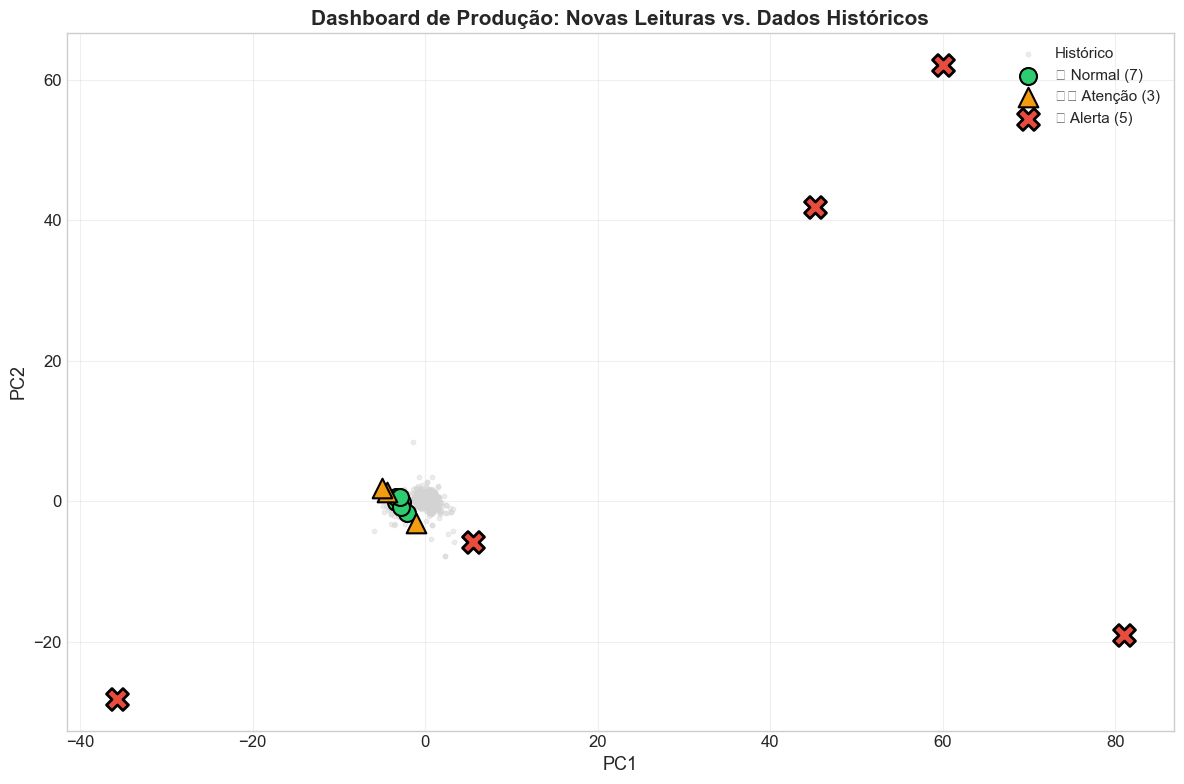

💡 Pontos vermelhos (X) são as anomalias — leituras que estão fora
   do padrão observado durante o treino do modelo.
   Em produção, esses pontos disparariam alertas automáticos!


In [68]:
# --- Passo 6: Visualização das predições em produção ---
import matplotlib.pyplot as plt

# Carregar o dataset original APENAS para contexto visual 
# (em produção real, podemos ter dados históricos salvos)
from sklearn.decomposition import PCA

# Treinar PCA nos dados históricos carregados do CSV para projetar as predições no mesmo espaço
df_historico = pd.read_csv(
    Path("Dataset/ADXL345_SensorData.csv")
)
X_hist = df_historico[config_loaded['feature_names_raw']].values
X_hist_scaled = scaler_loaded.transform(X_hist)

pca_prod = PCA(n_components=2)
X_hist_pca = pca_prod.fit_transform(X_hist_scaled)
X_prod_pca = pca_prod.transform(X_production_scaled)

fig, ax = plt.subplots(figsize=(12, 8))

# Dados históricos como fundo
ax.scatter(X_hist_pca[:, 0], X_hist_pca[:, 1], c='lightgray', s=10, alpha=0.4, label='Histórico')

# Predições normais
mask_normal = min_distances_pred <= threshold_95
if mask_normal.any():
    ax.scatter(X_prod_pca[mask_normal, 0], X_prod_pca[mask_normal, 1], 
               c='#2ecc71', s=150, marker='o', edgecolors='black', linewidths=1.5,
               label=f'✅ Normal ({mask_normal.sum()})', zorder=5)

# Predições de atenção
mask_atencao = (min_distances_pred > threshold_95) & (min_distances_pred <= threshold_99)
if mask_atencao.any():
    ax.scatter(X_prod_pca[mask_atencao, 0], X_prod_pca[mask_atencao, 1], 
               c='#f39c12', s=200, marker='^', edgecolors='black', linewidths=1.5,
               label=f'⚠️ Atenção ({mask_atencao.sum()})', zorder=6)

# Predições de alerta
mask_critico = min_distances_pred > threshold_99
if mask_critico.any():
    ax.scatter(X_prod_pca[mask_critico, 0], X_prod_pca[mask_critico, 1], 
               c='#e74c3c', s=250, marker='X', edgecolors='black', linewidths=2,
               label=f'🚨 Alerta ({mask_critico.sum()})', zorder=7)

ax.set_xlabel('PC1', fontsize=13)
ax.set_ylabel('PC2', fontsize=13)
ax.set_title('Dashboard de Produção: Novas Leituras vs. Dados Históricos', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Pontos vermelhos (X) são as anomalias — leituras que estão fora")
print("   do padrão observado durante o treino do modelo.")
print("   Em produção, esses pontos disparariam alertas automáticos!")

### 11.2 Predição com o Modelo de Features Engenheiradas

Agora vamos também demonstrar a predição com o modelo treinado nas **27 features engenheiradas**. Na prática, este modelo seria alimentado por um pipeline que:

1. Coleta uma janela de N leituras do sensor
2. Extrai as 27 features (RMS, média, FFT, etc.) — mesmo pipeline da Aula 5
3. Normaliza e envia ao K-Means

> **💡 Este modelo é mais robusto** porque as features capturam informação estatística e espectral. Mas requer o pipeline de feature engineering rodando antes.

In [69]:
# --- 11.2 Predição com modelo de features engenheiradas ---

# Carregar modelo e scaler de features
kmeans_feat_loaded = joblib.load(model_dir / 'kmeans_features.joblib')
scaler_feat_loaded = joblib.load(model_dir / 'scaler_features.joblib')

print("📦 Modelo de features engenheiradas carregado!")
print(f"   K-Means: {kmeans_feat_loaded.n_clusters} clusters")
print(f"   Features esperadas: {len(config_loaded['feature_names_eng'])} features")

# Simular dados já processados pelo pipeline de Feature Engineering
# (Na prática, isso viria do pipeline da Aula 5 rodando em produção)
# Vamos usar algumas amostras do dataset de features existente para demonstrar
df_feat_demo = pd.read_csv(Path("processed_data/vibration_features.csv"))

# Pegar 5 amostras aleatórias como se fossem "novas janelas processadas"
np.random.seed(99)
sample_indices = np.random.choice(len(df_feat_demo), size=5, replace=False)
df_new_features = df_feat_demo.iloc[sample_indices].copy()

# Pré-processar e prever
X_new_feat = df_new_features[config_loaded['feature_names_eng']].values
X_new_feat_scaled = scaler_feat_loaded.transform(X_new_feat)

clusters_feat_pred = kmeans_feat_loaded.predict(X_new_feat_scaled)
distances_feat_pred = kmeans_feat_loaded.transform(X_new_feat_scaled).min(axis=1)

# Mostrar resultados
results_feat = pd.DataFrame({
    'Amostra': [f'Janela {i+1}' for i in range(len(sample_indices))],
    'Rótulo Real': df_new_features['label'].values,
    'Cluster Previsto': clusters_feat_pred,
    'Distância ao Centróide': distances_feat_pred.round(4)
})

print("\n📊 Predições com modelo de Features Engenheiradas:")
display(results_feat)

print("\n💡 Observe que o modelo de features engenheiradas faz predições a nível")
print("   de JANELA (resumo de ~34 leituras), não de leitura individual.")
print("   Isto é mais robusto para decisões de qualidade.")

📦 Modelo de features engenheiradas carregado!
   K-Means: 2 clusters
   Features esperadas: 27 features

📊 Predições com modelo de Features Engenheiradas:


,Amostra,Rótulo Real,Cluster Previsto,Distância ao Centróide
0,Janela 1,yes,0,3.7673
1,Janela 2,yes,0,2.1931
2,Janela 3,yes,0,4.8249
3,Janela 4,yes,0,3.6225
4,Janela 5,yes,0,3.6297



💡 Observe que o modelo de features engenheiradas faz predições a nível
   de JANELA (resumo de ~34 leituras), não de leitura individual.
   Isto é mais robusto para decisões de qualidade.


---

## 12. Resumo e Conclusões

### 📝 O Que Aprendemos Nesta Aula

| Etapa | O que fizemos | Por que importa |
|-------|--------------|-----------------|
| **Fundamentos** | Diferenciamos supervisionado de não supervisionado | Saber quando usar cada abordagem |
| **K-Means** | Agrupamento com dados brutos (3 features) | O algoritmo mais intuitivo e popular |
| **Elbow Method** | Escolha de K com gráfico de inércia | Método sistemático para definir nº de clusters |
| **Silhueta** | Avaliação da qualidade dos clusters | Mede coesão E separação (melhor que inércia) |
| **DBSCAN** | Clustering por densidade + detecção de outliers | Ideal para anomalias — não precisa de K! |
| **Hierárquico** | Dendrograma e análise multi-nível | Visualizar a hierarquia natural dos dados |
| **Features Eng.** | K-Means nas 27 features da Aula 5 | Conexão com pipeline real + prévia da Aula 8 |
| **Comparação** | Supervisionado vs. não supervisionado | Cada um tem pontos fortes e fracos |
| **Produção** | Exportar, importar e gerar predições | Pipeline completo de deploy |

### 🔑 Conceitos-Chave

1. **Clustering não precisa de rótulos** — descobre padrões por similaridade matemática
2. **Padronização é obrigatória** — distância Euclidiana exige features na mesma escala
3. **K-Means vs. DBSCAN** — um força grupos, o outro detecta ruído; são complementares
4. **ARI permite comparar** clusters com rótulos reais (quando disponíveis)
5. **Threshold de distância** — transformar clustering em sistema de alerta de anomalias
6. **Salvar TODO o pipeline** — modelo + scaler + threshold + nomes das features

### 📊 Decisão Pedagógica: Por Que Usamos Ambos os Datasets?

| Dataset | Papel na Aula | Papel no Pipeline |
|---------|--------------|-------------------|
| **Dados brutos (1082 × 3)** | Ver e entender os algoritmos com muitos pontos e poucas dimensões | Monitor em tempo real (leitura a leitura) |
| **Features engenheiradas (32 × 27)** | Conectar com Aulas 5/6 e preparar para Aula 8 | Sistema de qualidade robusto (janela a janela) |

### 🔗 Próxima Aula (Aula 8): Redução de Dimensionalidade

Na Aula 8, vamos estudar **PCA e UMAP** em profundidade. Já vimos um preview nesta aula:
- Usamos PCA para **visualizar** clusters em 2D
- Vimos que 27 features podem ser comprimidas sem perda significativa
- Na Aula 8, aprenderemos:
  - Como escolher o número de componentes
  - PCA vs. UMAP: linear vs. não-linear
  - Aplicar redução como **pré-processamento** antes do clustering
  - Detectar **drift** (mudança gradual nos dados ao longo do tempo)

### 📂 Arquivos Exportados Nesta Aula

```
modelos_exportados/nao_supervisionado/
├── kmeans_raw.joblib           ← K-Means treinado nos dados brutos
├── kmeans_features.joblib      ← K-Means treinado nas features engenheiradas
├── scaler_raw.joblib           ← StandardScaler (dados brutos)
├── scaler_features.joblib      ← StandardScaler (features engenheiradas)
└── anomaly_config.joblib       ← Thresholds + nomes das features
```